In [1]:
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, factorize_psd_truncated, create_4q_gst_config, is_isometry, run_gds_jax
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
 
from mGST.low_level_jit import cost_function_jax_mps, gradient_all_3_and_value_jit, cost_function_numba, cost_function_jax
from mGST.algorithm import run_mGST

import jax.numpy as jnp

import numpy as np

import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

# Optimization comparisons (no regularized)

## Setup

In [3]:
# first let's calculate the cost function using numba
# Euclidean Gradient
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, seed=42
)

2025-03-03 20:06:23,503 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-03-03 20:06:24,021 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-03-03 20:06:24,021 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-03-03 20:06:25,734 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-03-03 20:06:25,744 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-03-03 20:06:25,775 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-03-03 20:06:31,768:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-03 20:06:31,768 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [4]:
# for Numba
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)
X_np = np.array(X)

E.shape, rho.shape, K.shape

((4, 16), (16,), (5, 4, 4, 4))

In [127]:
X_test = jnp.einsum("ijkl,ijnm -> iknlm", K_np, K_np.conj()).reshape((d, r, r))
jnp.allclose(X, X_test)

Array(True, dtype=bool)

In [ ]:
# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix_exact = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1).transpose(0, 2, 1)

jnp.allclose(state_psd @ state_psd.conj().T, state), jnp.allclose(povm_psd.conj().transpose(0, 2, 1) @ povm_psd, povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [459]:
state_psd @ state_psd.conj().T

Array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex128)

In [458]:
squeezed_state = state_psd.squeeze()
squeezed_state @ squeezed_state.conj().T

Array(1.+0.j, dtype=complex128)

## Intermezzo: testing factorization utilities

In [150]:
# testing factorized_psd_with_kraus
# superop to choi
num_gates_test, dim_squared_test, _ = X_np.shape
dim_test = int(jnp.sqrt(dim_squared_test))
superop_shape = (num_gates_test,) + (dim_test,)*4 
superop = X_np.reshape(superop_shape)  # num_gates, dim_out, dim_out*, dim_in, dim_in*
choi = superop.swapaxes(1, 4).reshape([num_gates_test, dim_test ** 2, dim_test ** 2]) # num_gates, dim_in* x dim_out*, dim_in x dim_out
choi_transpose = choi.swapaxes(1, 2) # this is needed to have input, ouput instead of output, input
rank = 4
choi_psd = factorize_psd_truncated(choi_transpose, max_rank=rank)
choi_psd = jnp.reshape(choi_psd, (num_gates_test, dim_test, dim_test, rank))
choi_psd = jnp.transpose(choi_psd, (0, 3, 2, 1))

jnp.allclose(K_np, choi_psd)

Array(False, dtype=bool)

In [152]:
# test if we obtain the same superop
superop_test = jnp.einsum("ijkl,ijnm -> iknlm", choi_psd, choi_psd.conj())
superop_test_matrix = superop_test.reshape((num_gates_test, dim_test ** 2, dim_test ** 2))
jnp.allclose(superop_test_matrix, X_np), jnp.allclose(superop_test, superop)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [153]:
from mGST.additional_fns import Kraus_rep

choi_psd_mgst = Kraus_rep(X_np, d=num_gates_test, pdim=dim_test, rK=rank)
superop_test_2 = jnp.einsum("ijkl,ijnm -> iknlm", choi_psd_mgst, choi_psd_mgst.conj()).reshape((num_gates_test, dim_squared_test, dim_squared_test))

jnp.allclose(choi_psd_mgst, K_np), jnp.allclose(choi_psd_mgst, choi_psd), jnp.allclose(superop_test_2, X_np)

(Array(False, dtype=bool), Array(False, dtype=bool), Array(True, dtype=bool))

In [168]:
# test utility function between jax and mgst
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

kraus_tensor_test, povm_psd_test, state_psd_test = get_compressed_rep_from_mgst_output(X, E, rho, kraus_rank=4)

superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_test, kraus_tensor_test.conj()).reshape((num_gates_test, dim_squared_test, dim_squared_test))

jnp.allclose(kraus_tensor_test, kraus_tensor), jnp.allclose(povm_psd_test, povm_psd), jnp.allclose(state_psd_test, state_psd), jnp.allclose(superop_kraus_test, X_np)

(Array(False, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool))

## End of intermezzo

## Optimization

In [9]:
cost_value_numba_2q_init = cost_function_numba(K_np, E_np, rho_np, J, y_np)
cost_value_numba_2q_init

0.001717284266348219

In [ ]:
cost_function_jax(X_np, E_np, rho_np, J, y_np), cost_function_jax(X_np, E_np, rho_np, indices_list, prob_matrix_exact)

(Array(0.00225798, dtype=float64), Array(0.00171728, dtype=float64))

In [ ]:
# jax version to compile first
cost_value_jax_2q_init = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix_exact, jit=True)
cost_value_jax_2q_init

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15


Array(0.00171728, dtype=float64)

In [10]:
jnp.allclose(cost_value_numba_2q_init, cost_value_jax_2q_init)

Array(True, dtype=bool)

In [15]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    y_np, indices_list, 0, d, r, rK, n_povm, bsize, meas_samples,
    init = [K_np, E_np, rho_np],
    method = "GD",
    max_iter=250,
    target_rel_prec=1e-4,
)

Starting mGST optimization...
100%|██████████| 70/70 [06:04<00:00,  5.21s/it]
	 Convergence criterion satisfied
	 Final objective 0.00014661018299007186 in time 365.78s


In [17]:
kraus_updated_2q_no_dmrg, povm_updated_2q_no_dmrg, state_updated_2q_no_dmrg, cost_fn_history_2q_no_dmrg = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=False, dmrg_like=False)

iteration:  0
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
optimized step size: [4.59564641 0.13756274 1.53250007]
cost:  0.00171728426634822
iteration:  1
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
optimized step size: [ 6.07479365 -0.85246385  4.68771893]
cost:  0.001216557682370511
iteration:  2
Initial count: 45
Initial count:

In [19]:
kraus_updated_2q_dmrg, povm_updated_2q_dmrg, state_updated_2q_dmrg, cost_fn_history_2q_dmrg = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=False, dmrg_like=True)

iteration:  0
Initial count: 45
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Povm: [19.00000001]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Kraus: [4.94726563]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Init

In [34]:
kraus_updated_2q_dmrg_geo, povm_updated_2q_dmrg_geo, state_updated_2q_dmrg_geo, cost_fn_history_2q_dmrg_geo = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=True, dmrg_like=True)

iteration:  0
Initial count: 45
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Povm: [19.00000001]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Kraus: [4.9482422]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initi

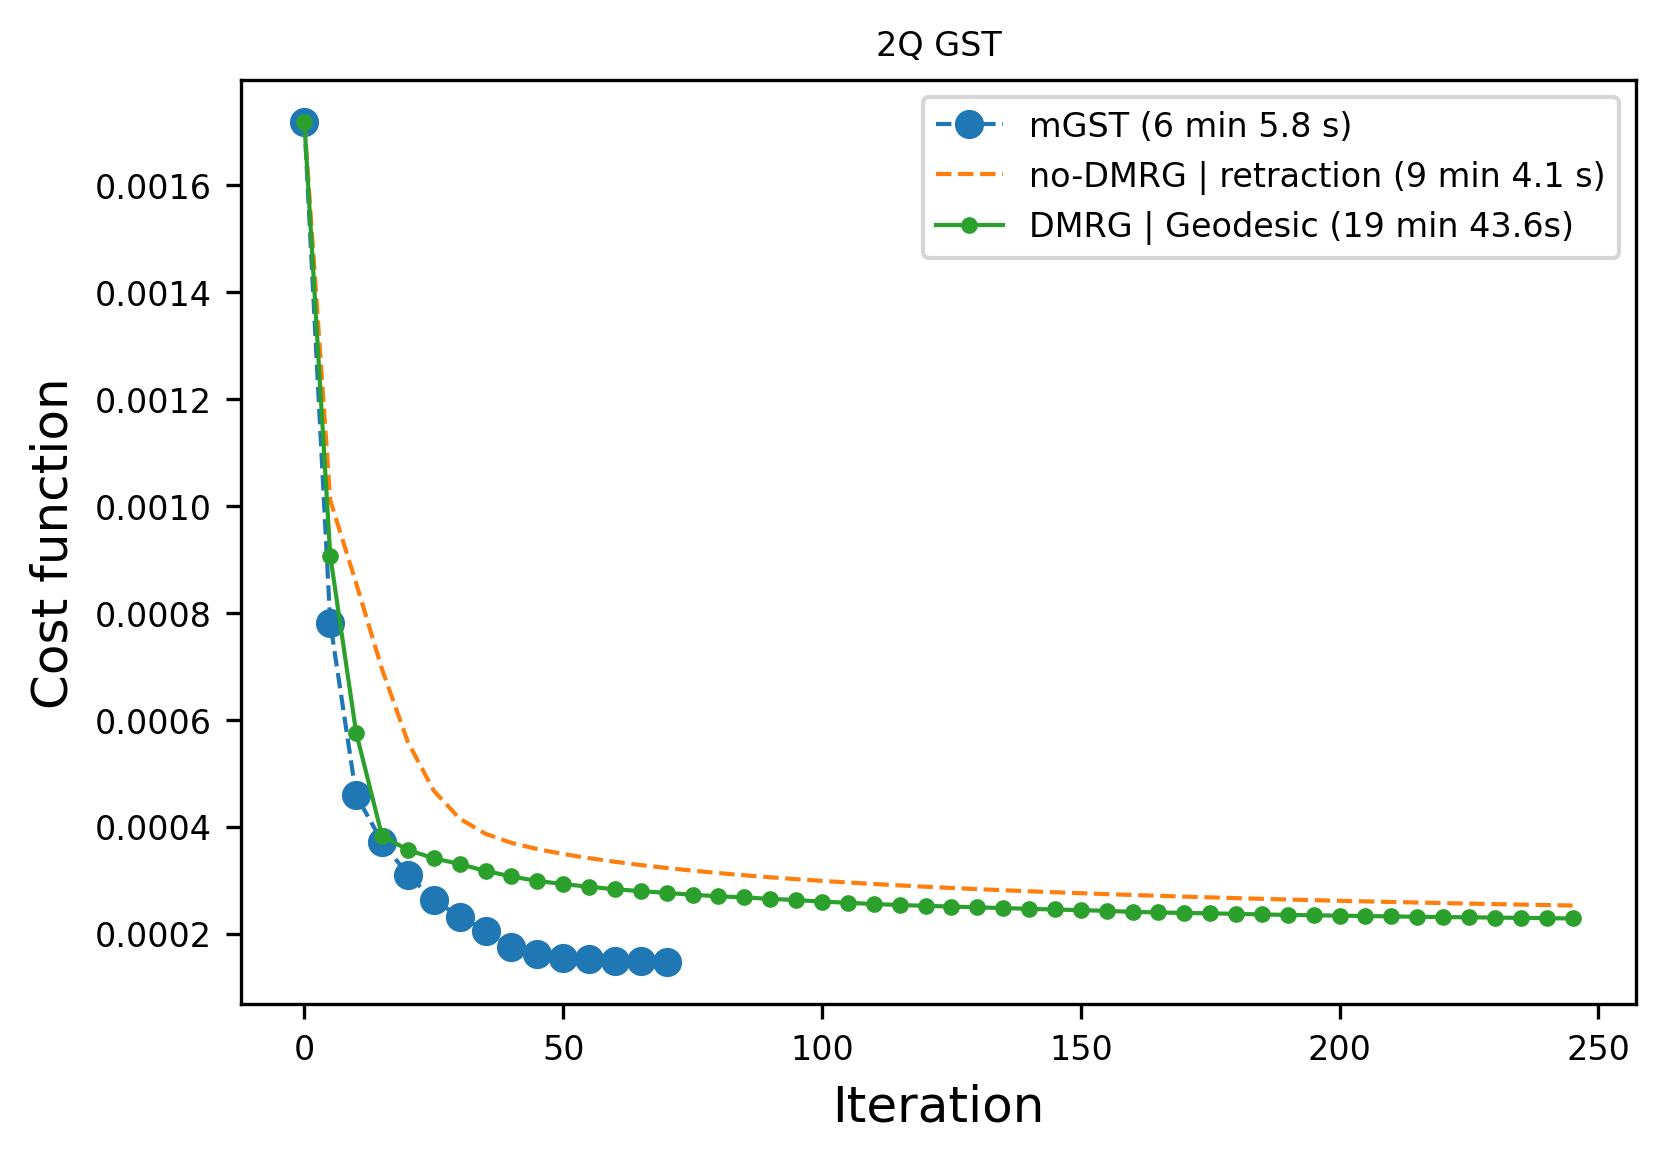

In [54]:
plot_step = 5

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(0,len(cost_fn_history_2q_mgst), plot_step), cost_fn_history_2q_mgst[::plot_step], "--o", linewidth=1, markersize=6, label="mGST (6 min 5.8 s)")
plt.plot(range(0, len(cost_fn_history_2q_no_dmrg), plot_step), cost_fn_history_2q_no_dmrg[::plot_step], "--", linewidth=1, markersize=6, label="no-DMRG | retraction (9 min 4.1 s)")
# plt.plot(range(0, len(cost_fn_history_2q_dmrg), plot_step), cost_fn_history_2q_dmrg[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="DMRG | retraction (18 min 13.6s)")
plt.plot(range(0, len(cost_fn_history_2q_dmrg_geo), plot_step), cost_fn_history_2q_dmrg_geo[::plot_step], marker="o", linestyle="-", linewidth=1, markersize=3, label="DMRG | Geodesic (19 min 43.6s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [51]:
povm_updated_2q_dmrg_geo[0].squeeze(), povm_psd[0].squeeze()

(Array([ 0.99985124-4.52737227e-05j,  0.00432698+4.08809705e-03j,
        -0.00472085-7.37343681e-03j,  0.01302755-3.95981645e-03j],      dtype=complex128),
 Array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex128))

In [39]:
# just to make the difference even more clear, let's compare the ratios
ratio_mgst = np.array(cost_fn_history_2q_mgst[-1]) / cost_fn_history_2q_mgst[0]
ratio_no_dmrg = np.array(cost_fn_history_2q_no_dmrg[-1]) / cost_fn_history_2q_no_dmrg[0]
ratio_dmrg = np.array(cost_fn_history_2q_dmrg[-1]) / cost_fn_history_2q_dmrg[0]
ratio_dmrg_geo = np.array(cost_fn_history_2q_dmrg_geo[-1]) / cost_fn_history_2q_dmrg_geo[0]

print(f"Initial cost: {cost_fn_history_2q_mgst[0]}")
print("----------------------")
print(f"* mGST: {ratio_mgst * 100:.3f} %")
print(f"* no-DMRG: {ratio_no_dmrg * 100:.3f} %")
print(f"* DMRG: {ratio_dmrg * 100:.3f} %")
print(f"* DMRG-Geo: {ratio_dmrg_geo * 100:.3f} %")

Initial cost: 0.0017172842663482199
----------------------
* mGST: 8.537 %
* no-DMRG: 14.665 %
* DMRG: 13.309 %
* DMRG-Geo: 13.269 %


In [ ]:
prob_matrix_exact.shape, num_povm, len(indices_list), prob_matrix_exact[:,0] # one, for each POVM, i.e. for each computational basis state.

((4, 800), 4, 800, array([0.908, 0.041, 0.05 , 0.001]))

# 2Q: Regularization

## Test mGST regularization

In [ ]:
from mGST.reporting.reporting import gauge_opt
from mGST.qiskit_interface import qiskit_gate_to_operator
from mGST.compatibility import arrays_to_pygsti_model
from iqm.benchmarks.compressive_gst.compressive_gst import CompressiveGST


# original gate set
benchmark = CompressiveGST(backend, Q2_GST)
gate_set = benchmark.gate_set
gate_set_length = len(gate_set)

K_target = qiskit_gate_to_operator(gate_set)
weights = dict({f"G%i" % i: 1 for i in range(gate_set_length)}, **{"spam": 1})
X_target = np.einsum("ijkl,ijnm -> iknlm", K_target, K_target.conj()).reshape(
        (gate_set_length, pdim**2, pdim**2)
    )

target_mdl = arrays_to_pygsti_model(X_target, E_np, rho_np, basis="std")

In [172]:
K_target.shape, jnp.allclose(K_target, kraus_tensor), jnp.linalg.norm(K_target - kraus_tensor)

((5, 1, 4, 4), Array(False, dtype=bool), Array(7.75054233, dtype=float64))

In [180]:
K_target[0][0], kraus_tensor[0][0]

(array([[0.70710678+0.j        , 0.        -0.70710678j,
         0.        +0.j        , 0.        +0.j        ],
        [0.        -0.70710678j, 0.70710678+0.j        ,
         0.        +0.j        , 0.        +0.j        ],
        [0.        +0.j        , 0.        +0.j        ,
         0.70710678+0.j        , 0.        -0.70710678j],
        [0.        +0.j        , 0.        +0.j        ,
         0.        -0.70710678j, 0.70710678+0.j        ]]),
 array([[ 0.01048914+0.j        , -0.01254466-0.00357556j,
         -0.00610251+0.0095865j , -0.00252074-0.00611728j],
        [ 0.00833846+0.00897308j, -0.0092227 +0.00505005j,
          0.00330324+0.00420333j, -0.01179954-0.00427122j],
        [-0.0002475 -0.00578244j, -0.00567752+0.00474536j,
         -0.00627448+0.00073757j, -0.0104812 +0.00288771j],
        [-0.00704502+0.00761719j,  0.01363442-0.0123344j ,
          0.00612187-0.00996815j,  0.00340318+0.00161388j]]))

In [89]:
%%timeit
X_opt, E_opt, rho_opt = gauge_opt(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, target_mdl, weights)

1.05 s ± 82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
X_opt, E_opt, rho_opt = gauge_opt(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, target_mdl, weights)

In [207]:
jnp.linalg.matrix_rank(rho_np), jnp.linalg.matrix_rank(state_updated_2q_mgst)

(Array(1, dtype=int32), Array(1, dtype=int32))

In [263]:
kraus_tensor_opt_mgst, povm_psd_opt_mgst, state_psd_opt_mgst  = get_compressed_rep_from_mgst_output(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, kraus_rank=4, state_rank=4, povm_rank=4)

In [262]:
kraus_opt_mgst_gauge, povm_opt_mgst_gauge, state_opt_mgst_gauge  = get_compressed_rep_from_mgst_output(X_opt, E_opt, rho_opt, kraus_rank=4, state_rank=4, povm_rank=4)

In [264]:
state_psd_opt_mgst.shape, state_updated_2q_mgst.shape, povm_updated_2q_mgst.shape, povm_psd_opt_mgst.shape

((4, 4), (16,), (4, 16), (4, 4, 4))

In [265]:
state_test = state_psd_opt_mgst @ state_psd_opt_mgst.conj().T
povm_test = povm_psd_opt_mgst.transpose(0, 2, 1).conj() @ povm_psd_opt_mgst
print(jnp.allclose(state_test, state_updated_2q_mgst.reshape(dim, dim)))
print(jnp.allclose(povm_test.conj(), povm_updated_2q_mgst.reshape(num_povm, dim, dim)))
# rank 3 is the minimum such that the result is still the same as the original

True
True


In [267]:
povm_test[0] - povm_updated_2q_mgst[0].reshape(dim, dim)

Array([[ 3.33066907e-16-3.46892835e-19j, -3.25260652e-19-1.02035883e-02j,
        -2.60208521e-18+1.82552251e-02j,  1.73472348e-18+8.78664114e-03j],
       [-3.25260652e-19+1.02035883e-02j,  2.77555756e-17-3.54718535e-21j,
        -5.20417043e-18+2.67314264e-03j, -4.82469967e-18-1.89605517e-03j],
       [-2.60208521e-18-1.82552251e-02j, -5.20417043e-18-2.67314264e-03j,
         2.77555756e-17+1.94600315e-19j, -2.16840434e-18-1.59565951e-03j],
       [ 1.73472348e-18-8.78664114e-03j, -4.82469967e-18+1.89605517e-03j,
        -2.16840434e-18+1.59565951e-03j,  5.25838054e-18+2.99929644e-21j]],      dtype=complex128)

In [ ]:
print(cost_function_jax(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, indices_list, prob_matrix_exact))
print(cost_function_jax(X_opt, E_opt, rho_opt, indices_list, prob_matrix_exact))
# they are the same, as expected, since we are within the same gauge class

0.00014661018299007186
0.00014661018299007148


In [ ]:
# we take the conjugate because the povm_psd we need for cost_function_jax_mps is povm_jax = povm_mgst
cost_function_jax_mps(
    kraus=kraus_tensor_opt_mgst, povm_psd=povm_psd_opt_mgst.conj(), state_psd=state_psd_opt_mgst, indices_list=indices_list, prob_matrix=prob_matrix_exact, jit=True
)

Initial count: 60


Array(0.00014661, dtype=float64)

In [ ]:
cost_function_jax_mps(
    kraus=kraus_opt_mgst_gauge, povm_psd=povm_opt_mgst_gauge.conj(), state_psd=state_opt_mgst_gauge, indices_list=indices_list, prob_matrix=prob_matrix_exact, jit=True
)

Initial count: 60


Array(0.00014661, dtype=float64)

In [273]:
povm_psd_opt_mgst_jax_conv = povm_psd_opt_mgst.conj()
povm_opt_mgst_gauge_jax_conv = povm_opt_mgst_gauge.conj()

## Test regularized cost function

In [ ]:
from mGST.low_level_jit import cost_function_jax_mps_regularized

# the value with the unoptimized parameters.
cost_function_jax_mps_regularized(
    kraus_tensor=kraus_tensor, povm_psd=povm_tensor, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix_exact,
    target_kraus_tensor=kraus_tensor, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)

Initial count: 60


Array(0.00171728, dtype=float64)

In [184]:
cost_value_jax_2q_init, cost_fn_history_2q_dmrg_geo[-1], cost_fn_history_2q_mgst[-1]

(Array(0.00171728, dtype=float64),
 Array(0.00022787, dtype=float64),
 Array(0.00014661, dtype=float64))

In [ ]:
# now with the optimized parameters
loss_value_opt = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_updated_2q_dmrg_geo, povm_psd=povm_updated_2q_dmrg_geo, state_psd=state_updated_2q_dmrg_geo, indices_list=indices_list, prob_matrix=prob_matrix_exact,
    target_kraus_tensor=kraus_tensor, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_opt

Initial count: 60


Array(0.00026068, dtype=float64)

In [ ]:
# although the actual comparisons should be done with the K_target!
loss_value_target = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_updated_2q_dmrg_geo, povm_psd=povm_updated_2q_dmrg_geo, state_psd=state_updated_2q_dmrg_geo, indices_list=indices_list, prob_matrix=prob_matrix_exact,
    target_kraus_tensor=K_target, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target

Initial count: 60


Array(0.00025787, dtype=float64)

In [ ]:
# what is the value of the regularized cost function with the mgst parameters (without gauge opt)
loss_value_target_mgst = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_tensor_opt_mgst, povm_psd=povm_psd_opt_mgst_jax_conv, state_psd=state_psd_opt_mgst, indices_list=indices_list, prob_matrix=prob_matrix_exact,
    target_kraus_tensor=K_target, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target_mgst

Initial count: 60


Array(0.00016623, dtype=float64)

In [ ]:
# now with the gauge opt mgst
loss_value_target_mgst = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_opt_mgst_gauge, povm_psd=povm_opt_mgst_gauge_jax_conv, state_psd=state_opt_mgst_gauge, indices_list=indices_list, prob_matrix=prob_matrix_exact,
    target_kraus_tensor=K_target, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target_mgst

Initial count: 60


Array(0.00016345, dtype=float64)

## Test regularized gradient

In [290]:
from mGST.low_level_jit import gradient_k_mps_jit_reg, gradient_povm_mps_jit_reg, gradient_state_mps_jit_reg

In [ ]:
ambient_gradient_kraus_regularized = gradient_k_mps_jit_reg(
    kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix_exact,
    target_kraus_tensor=K_target, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples,
    )
ambient_gradient_kraus_regularized

Initial count: 75


Array([[[[-2.26821793e-05-5.50338037e-05j,
          -5.12330786e-06+4.27269884e-06j,
           1.64965200e-06+1.21239858e-05j,
          -6.80419791e-06-3.37244084e-06j],
         [ 1.00619153e-04-2.36203444e-05j,
          -4.54343490e-05-4.31022912e-05j,
           9.94612260e-06-1.35086999e-05j,
           1.09878059e-08-3.99106057e-06j],
         [-7.80870328e-06-1.65398671e-05j,
           1.05847403e-05+6.21751891e-06j,
           8.03228853e-06-1.48185939e-05j,
           2.69983004e-07-7.35708831e-06j],
         [ 1.22376237e-05-5.66456947e-07j,
          -2.81835828e-05-2.53147001e-05j,
           3.91228451e-05-1.76459592e-05j,
          -2.17725601e-05-3.08915938e-05j]],

        [[-4.38676716e-05+9.36039436e-05j,
          -3.90919876e-06-5.37823499e-05j,
           3.06803542e-05+4.73023084e-07j,
           1.78188897e-07-9.81985746e-06j],
         [-8.15968653e-05-2.27194114e-05j,
          -2.13874879e-05-2.21051173e-05j,
           3.39102191e-06+2.89234106e-05j,
    

In [295]:
type(K_target), type(povm_psd), type(state_psd)

(numpy.ndarray, jaxlib.xla_extension.ArrayImpl, jaxlib.xla_extension.ArrayImpl)

In [ ]:
ambient_gradient_povm_regularized = gradient_povm_mps_jit_reg(
    kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix_exact,
    target_kraus_tensor=jnp.array(K_target), target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples,
    )
ambient_gradient_povm_regularized

Initial count: 75


Array([[[nan+nanj, nan+nanj, nan+nanj, nan+nanj]],

       [[nan+nanj, nan+nanj, nan+nanj, nan+nanj]],

       [[nan+nanj, nan+nanj, nan+nanj, nan+nanj]],

       [[nan+nanj, nan+nanj, nan+nanj, nan+nanj]]], dtype=complex128)

In [ ]:
ambient_gradient_state_regularized = gradient_state_mps_jit_reg(
    kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix_exact,
    target_kraus_tensor=K_target, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples,
    )
ambient_gradient_state_regularized

Initial count: 75


Array([[nan+nanj],
       [nan+nanj],
       [nan+nanj],
       [nan+nanj]], dtype=complex128)

## Debugging the Nan's

In [ ]:
from mGST.low_level_jit import frobenius_distance_expanded
import jax

In [ ]:
state_estimate = state_psd @ state_psd.conj().T
target_state_psd = state_psd
state_target = target_state_psd @ target_state_psd.conj().T
frobenius_distance_expanded(state_estimate, state_target)

Array(0., dtype=float64)

In [306]:
state_estimate_opt = state_updated_2q_dmrg_geo @ state_updated_2q_dmrg_geo.conj().T
jnp.trace(state_estimate), jnp.trace(state_estimate_opt)

(Array(1.+0.j, dtype=complex128), Array(1.-1.43007404e-21j, dtype=complex128))

In [ ]:
jax.grad(frobenius_distance_expanded)(state_estimate, state_target)

Array([[nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, nan+nanj]], dtype=complex128)

In [317]:
from jax import make_jaxpr

def frobenius_norm_like(estimate:jnp.ndarray, target:jnp.ndarray):
    
    return jnp.real(jnp.trace(estimate.conj().T @ estimate) - 2 * jnp.trace(estimate.conj().T @ target).real)

# make_jaxpr(jax.grad(jnp.linalg.norm))(jnp.zeros_like(state_estimate))
jax.grad(frobenius_norm_like)(state_estimate, state_target)

Array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex128)

In [ ]:
make_jaxpr(jax.grad(frobenius_distance_expanded))(state_estimate, state_target)

let trace = { lambda ; a:c128[4,4]. let
    b:i64[4,4] = iota[dimension=0 dtype=int64 shape=(4, 4) sharding=None] 
    c:i64[4,4] = iota[dimension=1 dtype=int64 shape=(4, 4) sharding=None] 
    d:i64[4,4] = add b 0
    e:bool[4,4] = eq d c
    f:c128[4,4] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(4, 4)
      sharding=None
    ] 0j
    g:c128[4,4] h:c128[4,4] = pjit[
      name=_where
      jaxpr={ lambda ; i:bool[4,4] j:c128[4,4] k:c128[4,4]. let
          l:c128[4,4] = select_n i k j
          m:c128[4,4] = broadcast_in_dim[
            broadcast_dimensions=()
            shape=(4, 4)
            sharding=None
          ] 0j
        in (l, m) }
    ] e a f
    n:c128[] = reduce_sum[axes=(0, 1)] g
  in (n, e, h) } in
let trace1 = { lambda ; o:bool[4,4] p:c128[4,4] q:c128[]. let
    r:c128[4,4] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(4, 4)
      sharding=None
    ] q
    s:c128[4,4] = pjit[
      name=_where
      jaxpr={ lambda ; t:bool[4,4] 

## Testing fidelity of quantum channel

### Test correctness

In [ ]:
num_gates, _, dim_out, dim_in = kraus_tensor.shape
target_kraus_tensor = jnp.array(K_target)
kraus_estimate = jnp.einsum("ijkl, ijnm -> iknlm", kraus_tensor, kraus_tensor.conj()).reshape((num_gates, dim_out**2, dim_in**2))
kraus_target = jnp.einsum("ijkl, ijnm -> iknlm", target_kraus_tensor, target_kraus_tensor.conj()).reshape((num_gates, dim_out**2, dim_in**2))

norm_f = frobenius_distance(kraus_estimate[0], kraus_target[0])**2
norm_pseudo_f = frobenius_norm_like(kraus_estimate[0], kraus_target[0])
norm_f_target = jnp.trace(kraus_target[0].conj().T @ kraus_target[0]) # frobenius norm of single kraus operator
norm_f, norm_pseudo_f, norm_f_target, jnp.allclose(norm_f_target + norm_pseudo_f, norm_f)

(Array(0.02140414, dtype=float64),
 Array(-15.97859586, dtype=float64),
 Array(16.+0.j, dtype=complex128),
 Array(True, dtype=bool))

In [322]:
jnp.allclose(norm_f_target, jnp.linalg.norm(kraus_target[0])**2)

Array(True, dtype=bool)

In [ ]:
[jnp.trace(kraus.conj().T @ kraus) for kraus in kraus_target] # as expected

[Array(16.+0.j, dtype=complex128),
 Array(16.+0.j, dtype=complex128),
 Array(16.+0.j, dtype=complex128),
 Array(16.+0.j, dtype=complex128),
 Array(16.+0.j, dtype=complex128)]

In [ ]:
[jnp.trace(kraus.conj().T @ kraus) for kraus in kraus_estimate] # ?

[Array(15.91009947+0.j, dtype=complex128),
 Array(15.91009947+0.j, dtype=complex128),
 Array(15.91009947+0.j, dtype=complex128),
 Array(15.91009947+0.j, dtype=complex128),
 Array(15.91009947+0.j, dtype=complex128)]

In [339]:
kraus_optimized = jnp.einsum("ijkl, ijnm -> iknlm", kraus_updated_2q_dmrg_geo, kraus_updated_2q_dmrg_geo.conj()).reshape((num_gates, dim_out**2, dim_in**2))

[jnp.trace(kraus.conj().T @ kraus) for kraus in kraus_optimized] # ?

[Array(15.49626697+0.j, dtype=complex128),
 Array(15.60346064+0.j, dtype=complex128),
 Array(15.49222292+0.j, dtype=complex128),
 Array(15.59742672+0.j, dtype=complex128),
 Array(15.06756072+0.j, dtype=complex128)]

In [340]:
kraus_target.shape, kraus_estimate.shape

((5, 16, 16), (5, 16, 16))

### Testing timing performance

In [367]:
# testing the best path for contraction
gate_idx = 0
K1 = kraus_tensor[gate_idx]
K2 = target_kraus_tensor[gate_idx]

path, path_info = jnp.einsum_path("ajk, bjk, alm, blm-> ", K2.conj(), K1, K2, K1.conj())
print(path)
print(path_info)

[(0, 1), (0, 1), (0, 1)]
  Complete contraction:  ajk,bjk,alm,blm->
         Naive scaling:  6
     Optimized scaling:  4
      Naive FLOP count:  4.096e+3
  Optimized FLOP count:  2.640e+2
   Theoretical speedup:  1.552e+1
  Largest intermediate:  4.000e+0 elements
--------------------------------------------------------------------------------
scaling        BLAS                current                             remaining
--------------------------------------------------------------------------------
   4           GEMM            bjk,ajk->ba                          alm,blm,ba->
   4           GEMM            blm,alm->ba                               ba,ba->
   2            DOT                ba,ba->                                    ->


In [368]:
fidelity_optimal_path = jnp.einsum("ajk, bjk, alm, blm-> ", K2.conj(), K1, K2, K1.conj(), optimize=path)

S1 = jnp.einsum("jkl, jnm -> knlm", K1, K1.conj())
S2 = jnp.einsum("jlk, jmn -> lmkn", K2.conj(), K2)
fidelity_naive = jnp.einsum("lmkn, knlm -> ", S2, S1)
jnp.allclose(fidelity_optimal_path, fidelity_naive)

Array(True, dtype=bool)

In [354]:
# lets' quickly test the timing of each of these operations
%timeit jnp.einsum("ajk, bjk, alm, blm-> ", K2.conj(), K1, K2, K1.conj(), optimize=path)

267 μs ± 19.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [353]:
%%timeit
S1 = jnp.einsum("jkl, jnm -> knlm", K1, K1.conj())
S2 = jnp.einsum("jlk, jmn -> lmkn", K2.conj(), K2)
jnp.einsum("lmkn, knlm -> ", S2, S1)

631 μs ± 9.79 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [358]:
kraus_tensor.shape

(5, 4, 4, 4)

In [375]:
# what if instead we obtain all together?
%timeit jnp.einsum("iajk, ibjk, ialm, iblm-> ", target_kraus_tensor.conj(), kraus_tensor, target_kraus_tensor, kraus_tensor.conj(), optimize=path)

286 μs ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
# what if instead we obtain all together?
%timeit jnp.einsum("...ajk, ...bjk, ...alm, ...blm-> ", target_kraus_tensor.conj(), kraus_tensor, target_kraus_tensor, kraus_tensor.conj(), optimize=path)

296 μs ± 1.99 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [361]:
%%timeit
total_fidelity = 0
for K1, K2 in zip(kraus_tensor, target_kraus_tensor):
    total_fidelity += jnp.einsum("ajk, bjk, alm, blm-> ", K2.conj(), K1, K2, K1.conj(), optimize=path)
# same evaluation but for loop

1.61 ms ± 18.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [372]:
267 * 1e-6 * 5 * 1e3 # ms

1.3349999999999997

In [551]:
def _kraus_distance_frobenius(kraus_tensor_est, kraus_tensor_target):
    
    # Kraus
    num_gates, _, dim_out, dim_in = kraus_tensor_est.shape
    kraus_estimate = jnp.einsum("ijkl, ijnm -> iknlm", kraus_tensor_est, kraus_tensor_est.conj()).reshape((num_gates, dim_out**2, dim_in**2))
    kraus_target = jnp.einsum("ijkl, ijnm -> iknlm", kraus_tensor_target, kraus_tensor_target.conj()).reshape((num_gates, dim_out**2, dim_in**2))
    regularized_value = 0
    for op_estimate, op_target in zip(kraus_estimate, kraus_target):
        regularized_value += frobenius_distance_expanded(op_estimate, op_target)
    regularized_value /= 2 * dim_in ** 2
    return regularized_value
_kraus_distance_frobenius(kraus_updated_2q_dmrg_geo, target_kraus_tensor)

Array(0.00299715, dtype=float64)

In [553]:
%timeit _kraus_distance_frobenius(kraus_updated_2q_dmrg_geo, target_kraus_tensor)

4.99 ms ± 475 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [554]:
4.99e-3 / 296e-6

16.85810810810811

In [373]:
total_fidelity_for_loop = 0
for K1, K2 in zip(kraus_tensor, target_kraus_tensor):
    total_fidelity_for_loop += jnp.einsum("ajk, bjk, alm, blm-> ", K2.conj(), K1, K2, K1.conj(), optimize=path)

total_fidelity_contraction = jnp.einsum("...ajk, ...bjk, ...alm, ...blm-> ", target_kraus_tensor.conj(), kraus_tensor, target_kraus_tensor, kraus_tensor.conj(), optimize=path)
jnp.allclose(total_fidelity_contraction, total_fidelity_for_loop)

Array(True, dtype=bool)

In [552]:
total_fidelity_contraction

Array(79.72173832+0.j, dtype=complex128)

## Testing fidelity of POVM's

### Test contraction

In [378]:
povm_psd.shape, povm_updated_2q_dmrg_geo.shape

((4, 1, 4), (4, 1, 4))

In [380]:
jnp.einsum_path(
    "...aj, ...bj, ...ak, ...bk->", 
    povm_psd.conj(), povm_updated_2q_dmrg_geo, 
    povm_psd, povm_updated_2q_dmrg_geo.conj(),
)

([(0, 1), (0, 1), (0, 1)],
   Complete contraction:  eaj,ebj,eak,ebk->
          Naive scaling:  5
      Optimized scaling:  4
       Naive FLOP count:  2.560e+2
   Optimized FLOP count:  7.200e+1
    Theoretical speedup:  3.556e+0
   Largest intermediate:  4.000e+0 elements
 --------------------------------------------------------------------------------
 scaling        BLAS                current                             remaining
 --------------------------------------------------------------------------------
    4              0           ebj,eaj->eba                         eak,ebk,eba->
    4              0           ebk,eak->eba                             eba,eba->
    3            DOT              eba,eba->                                    ->)

In [379]:
optimal_path = [(0, 1), (0, 1), (0, 1)]

jnp.einsum(
    "...aj, ...bj, ...ak, ...bk->", 
    povm_psd.conj(), povm_updated_2q_dmrg_geo, 
    povm_psd, povm_updated_2q_dmrg_geo.conj(), optimize=optimal_path
)

Array(3.99877193-1.29283425e-21j, dtype=complex128)

In [ ]:
idx = 0
povm_tensor_target = povm_psd[idx]
povm_estimate = povm_updated_2q_dmrg_geo[idx]

### Timing performance

In [389]:
%timeit jnp.einsum("aj, bj, ak, bk->", povm_target.conj(), povm_estimate, povm_target, povm_estimate.conj(), optimize=optimal_path)

292 μs ± 28.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [381]:
%timeit jnp.einsum("...aj, ...bj, ...ak, ...bk->", povm_psd.conj(), povm_updated_2q_dmrg_geo, povm_psd, povm_updated_2q_dmrg_geo.conj(), optimize=optimal_path)

335 μs ± 9.39 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [383]:
%%timeit
for povm_est, povm_target in zip(povm_psd, povm_updated_2q_dmrg_geo):
    jnp.einsum("aj, bj, ak, bk->", povm_est.conj(), povm_target, povm_est, povm_target, optimize=optimal_path)

1.04 ms ± 12.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
povm_fidelity_contraction = jnp.einsum("...aj, ...bj, ...ak, ...bk->", povm_psd.conj(), povm_updated_2q_dmrg_geo, povm_psd, povm_updated_2q_dmrg_geo.conj(), optimize=optimal_path)

povm_fidelity_for_loop = 0
for povm_tensor_est, povm_tensor_target in zip(povm_psd, povm_updated_2q_dmrg_geo):
    povm_fidelity_for_loop += jnp.einsum("aj, bj, ak, bk->", povm_tensor_est.conj(), povm_tensor_target, povm_tensor_est, povm_tensor_target, optimize=optimal_path)
    
jnp.allclose(povm_fidelity_contraction, povm_fidelity_for_loop)

Array(True, dtype=bool)

In [546]:
# comparing against Frobenius norm
from mGST.low_level_jit import frobenius_distance_expanded

def _povm_distance_frobenius(povm_psd_estimate, povm_psd_target):
    # POVM
    num_povm = povm_psd.shape[0]
    povm_estimate = povm_psd_estimate.conj().transpose(0, 2, 1) @ povm_psd_estimate
    povm_target = povm_psd_target.conj().transpose(0, 2, 1) @ povm_psd_target
    regularized_value = 0
    for op_estimate, op_target in zip(povm_estimate, povm_target):
        regularized_value += frobenius_distance_expanded(op_estimate, op_target)
    regularized_value *=  0.5 / num_povm
    return regularized_value

_povm_distance_frobenius(povm_updated_2q_dmrg_geo, povm_psd)

Array(0.00030702, dtype=float64)

In [548]:
%timeit _povm_distance_frobenius(povm_updated_2q_dmrg_geo, povm_psd)

3.37 ms ± 349 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Fidelity of state

In [488]:
from mGST.low_level_jit import state_fidelity, state_fidelity_from_density_matrices
from mGST.utility_functions_comparisons import split_matrix_svd
state_updated_2q_dmrg_geo.shape, state_psd.shape, state_opt_mgst_gauge.shape

((4, 1), (4, 1), (4, 4))

In [477]:
state_fidelity(state_psd, state_psd)

Array(1., dtype=float64)

### Test against the jax implementation

In [478]:
# I am trying to investigate if the fidelity of two density matrices is the same 
# using the trace norm of the square root of the square roots, 
# compare with the sqaure root of square roots.

fidelity_tr_norm = state_fidelity(state_updated_2q_dmrg_geo, state_psd)
fidelity_tr_norm

Array(0.99972971, dtype=float64)

In [ ]:
rho_jax = state_updated_2q_dmrg_geo @ state_updated_2q_dmrg_geo.conj().T
rho_init = state_psd @ state_psd.conj().T
rho_mgst = state_psd_opt_mgst @ state_psd_opt_mgst.conj().T
rho_mgst_gauge = state_opt_mgst_gauge @ state_opt_mgst_gauge.conj().T

fidelity = state_fidelity_from_density_matrices(rho_jax, rho_init)
fidelity

Array(0.99972971+2.87952279e-20j, dtype=complex128)

In [493]:
rho_test = rho_jax @ rho_init
jnp.allclose(rho_test, rho_test.conj().T)

Array(False, dtype=bool)

In [499]:
u, s, _ = jnp.linalg.svd(rho_jax @ rho_init)
s**2

Array([0.99972971, 0.        , 0.        , 0.        ], dtype=float64)

In [ ]:
sqrt_test = factorize_psd_truncated(rho_jax @ rho_init, unique_srt=True)
jnp.allclose(sqrt_test @ sqrt_test, rho_jax @ rho_init)

Array(False, dtype=bool)

In [473]:
# now test with the "simpler version"
fidelity_sqrt_trace = jnp.trace(jnp.abs(state_updated_2q_dmrg_geo.conj().T @ state_psd))**2
jnp.allclose(fidelity_tr_norm, fidelity_sqrt_trace), fidelity_sqrt_trace

(Array(True, dtype=bool), Array(0.99972971, dtype=float64))

### Now with mgst matrix

In [ ]:
fidelity_tr_norm = state_fidelity(state_psd_opt_mgst, state_psd)
fidelity = state_fidelity_from_density_matrices(rho_mgst, rho_init)
fidelity_tr_norm, fidelity

(Array(0.99838659, dtype=float64), Array(0.99838659+0.j, dtype=complex128))

In [465]:
(state_psd_opt_mgst.conj().T @ state_psd).shape

(4, 1)

In [503]:
# now test with the "simpler version"
fidelity_sqrt_trace = jnp.trace(jnp.abs(state_psd_opt_mgst.conj().T @ state_psd))**2
jnp.allclose(fidelity_tr_norm, fidelity_sqrt_trace), fidelity_sqrt_trace

(Array(True, dtype=bool), Array(0.99838636, dtype=float64))

In [505]:
u, s, _ = jnp.linalg.svd(rho_mgst @ rho_init)
s

Array([0.99851223, 0.        , 0.        , 0.        ], dtype=float64)

### now with non pure states

In [463]:
state_opt_mgst_gauge.shape, state_psd_opt_mgst.shape

((4, 4), (4, 4))

In [ ]:
fidelity_tr_norm = state_fidelity(state_opt_mgst_gauge, state_psd_opt_mgst)
fidelity = state_fidelity_from_density_matrices(rho_mgst, rho_mgst_gauge)
fidelity_sqrt_trace = jnp.trace(jnp.abs(state_opt_mgst_gauge.conj().T @ state_psd_opt_mgst))**2
jnp.allclose(fidelity_tr_norm, fidelity_sqrt_trace), jnp.allclose(fidelity, fidelity_tr_norm), fidelity_sqrt_trace, fidelity_tr_norm, fidelity_fb

(Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(0.99994957, dtype=float64),
 Array(0.99994975, dtype=float64),
 Array(0.99994975-1.69402333e-21j, dtype=complex128))

In [521]:
def sqrtm_psd(matrix: jnp.ndarray, check_finite: bool = True) -> jnp.ndarray:
    """
    Calculates the square root of a matrix that is positive semidefinite.

    :param matrix: the matrix to square root
    :param check_finite: Whether to check that the ijnput matrices contain only finite numbers.
    :return: sqrt(matrix)
    """
    w, v = jnp.linalg.eigh(matrix)
    # As we further know that your matrix is positive semidefinite,
    # we can guard against precision errors by doing
    w = jnp.maximum(w, 0)
    w = jnp.sqrt(w)
    matrix_sqrt = (v * w).dot(v.conj().T)
    return matrix_sqrt

def fidelity_fb(rho: jnp.ndarray, sigma: jnp.ndarray, tol: float = 1000) -> float:
    r"""
    Computes the fidelity :math:`F(\rho, \sigma)` between two quantum states rho and sigma.

    If the states are pure the expression reduces to

    .. math::

        F(|psi>,|phi>) = |<psi|phi>|^2

    The fidelity obeys :math:`0 ≤ F(\rho, \sigma) ≤ 1`, where
    :math:`F(\rho, \sigma)=1 iff \rho = \sigma`.

    :param rho: Is a dim by dim positive matrix with unit trace.
    :param sigma: Is a dim by dim positive matrix with unit trace.
    :param tol: Tolerance in machine epsilons for jnp.real_if_close.
    :return: Fidelity which is a scalar.
    """
    sqrt_rho = sqrtm_psd(rho)
    return (jnp.trace(sqrtm_psd(sqrt_rho @ sigma @ sqrt_rho))) ** 2

fidelity_fb(rho_jax, rho_init), fidelity_fb(rho_mgst, rho_init), fidelity_fb(rho_mgst_gauge, rho_mgst)

(Array(0.99972971+0.j, dtype=complex128),
 Array(0.99838659-1.69269873e-20j, dtype=complex128),
 Array(0.99994975-3.38804666e-21j, dtype=complex128))

### Benchmarking against random PSD matrices

In [533]:
import jax.random as random

def random_psd_matrix(seed:int, rows: int, rank: int = None) -> jnp.ndarray:
    """
    Generate a random complex positive semi-definite (PSD) matrix of shape (size, size).

    Args:
        seed: Seed for the random generation using jax.
        size: The size of the matrix (N x N).

    Returns:
        jnp.ndarray: A (size, size) complex PSD matrix.
    """
    # Create a random key
    key = random.PRNGKey(seed)  # You can use any integer seed
    key_real, key_imag = random.split(key)
    
    # Generate a random complex matrix A
    if rank is None:
        rank = rows
    A_real = random.normal(key_real, shape=(rows, rank))
    A_imag = random.normal(key_imag, shape=(rows, rank))
    A = A_real + 1j * A_imag

    # Construct PSD matrix: M = A A^†
    M = A @ A.conj().T

    return M, A

test_matrix, test_sqrt = random_psd_matrix(0, 4, 2)

s = jnp.linalg.svd(test_matrix, compute_uv=False)
jnp.allclose(test_matrix, test_matrix.conj().T), s

(Array(True, dtype=bool),
 Array([8.72694319e+00, 3.50847484e+00, 7.42190133e-16, 7.54914065e-17],      dtype=float64))

In [534]:
def simple_fidelity(sqrt_1, sqrt_2):
    return jnp.trace(jnp.abs(sqrt_1.conj().T @ sqrt_2))**2

In [537]:
test_matrix, test_sqrt = random_psd_matrix(0, 4, 1)
test_matrix_2, test_sqrt_2 = random_psd_matrix(42 + 0, 4, 4)

simple_fidelity(test_sqrt, test_sqrt_2), fidelity_fb(test_matrix, test_matrix_2)

(Array(42.27164692, dtype=float64),
 Array(113.62306408+4.73372985e-15j, dtype=complex128))

In [ ]:
dim = 8

for seed in range(42):
    for rank in range(1, dim):
        for rank_2 in range(1, dim):
            test_matrix, test_sqrt = random_psd_matrix(seed, dim, rank)
            test_matrix_2, test_sqrt_2 = random_psd_matrix(seed + 42, dim, rank_2)
            
            fidelity_uhlmann = fidelity_fb(test_matrix, test_matrix_2)
            fidelity_tr_norm = state_fidelity(test_sqrt, test_sqrt_2)
            fidelity_density_matrices = state_fidelity_from_density_matrices(test_matrix, test_matrix_2)
            # fidelity_sqrt_trace = simple_fidelity(test_sqrt, test_sqrt_2)
            try:
                assert all(
                    [
                        jnp.allclose(fidelity_uhlmann, fidelity_tr_norm),
                        jnp.allclose(fidelity_uhlmann, fidelity_density_matrices),
                        # jnp.allclose(fidelity_uhlmann, fidelity_sqrt_trace),
                    ]
                )
               
            except AssertionError:
                print(f"Seed: {seed}, Rank 1: {rank}, Rank 2: {rank_2}")
                print(f"Fidelity Uhlmann: {fidelity_uhlmann}")
                print(f"Fidelity Tr Norm: {fidelity_tr_norm}")
                print(f"Fidelity Density Matrices: {fidelity_density_matrices}")
                print(f"Fidelity Simple: {fidelity_sqrt_trace}")
                print("")
            else:
                pass
                # print("success: ", seed, rank, rank_2)
            

### Timing performance

In [549]:
# comparing against Frobenius norm

def _state_distance_frobenius(state_psd_est, state_psd_target):
    state_estimate = state_psd_est @ state_psd_est.conj().T
    state_target = state_psd_target @ state_psd_target.conj().T
    return frobenius_distance_expanded(state_estimate, state_target)

_state_distance_frobenius(state_updated_2q_dmrg_geo, state_psd)

Array(0.00054058, dtype=float64)

In [550]:
%timeit _state_distance_frobenius(state_updated_2q_dmrg_geo, state_psd)

883 μs ± 5.87 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [542]:
%timeit state_fidelity(state_opt_mgst_gauge, state_psd_opt_mgst)

169 μs ± 1.67 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
%timeit fidelity_fb(rho_mgst_gauge, rho_mgst)

396 μs ± 1.06 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [544]:
%timeit state_fidelity_from_density_matrices(rho_mgst_gauge, rho_mgst)

1.17 ms ± 38.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [422]:
%timeit jnp.trace(state_opt_mgst_gauge.conj().T @ state_psd)**2

121 μs ± 538 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Results

* Frobenius expression (previously implemented): 883 μs ± 5.87 μs
* Trace norm of sqrt (state_fidelity): 169 μs ± 1.67 μs

### Additional tests to check for validity of contractions

In [452]:
state_updated_2q_dmrg_geo.shape, state_psd.shape

((4, 1), (4, 1))

In [440]:
fidelity_sqrt_trace = jnp.trace(state_updated_2q_dmrg_geo.conj().T @ state_psd)**2
fidelity_test = jnp.einsum("ij,ij->", state_updated_2q_dmrg_geo.conj(), state_psd)**2
# jnp.allclose(fidelity_test, fidelity_sqrt_trace)
fidelity_sqrt_trace, fidelity_test

(Array(0.99972971+5.08582777e-05j, dtype=complex128),
 Array(0.99972971+5.08582777e-05j, dtype=complex128))

In [461]:
state_opt_mgst_gauge.shape, state_psd.shape, state_psd_opt_mgst.shape

((4, 4), (4, 1), (4, 4))

In [455]:
(state_opt_mgst_gauge.conj().T @ state_psd).shape

(4, 1)

In [450]:
fidelity_sqrt_trace = jnp.trace(state_opt_mgst_gauge.conj().T @ state_psd)
fidelity_test = jnp.einsum("ij,ij->", state_opt_mgst_gauge.conj(), state_psd)
# jnp.allclose(fidelity_test, fidelity_sqrt_trace)
fidelity_sqrt_trace, fidelity_test

(Array(0.99924547+0.j, dtype=complex128),
 Array(0.99949973+0.j, dtype=complex128))

In [462]:
state_opt_mgst_gauge.conj().T @ state_psd

Array([[ 9.99245474e-01+0.j],
       [ 2.72723524e-04+0.j],
       [-1.84633314e-05+0.j],
       [ 9.07520978e-11+0.j]], dtype=complex128)

In [460]:
fidelity_sqrt_trace = jnp.trace(state_opt_mgst_gauge.conj().T @ state_psd_opt_mgst)
fidelity_test = jnp.einsum("ij,ij->", state_opt_mgst_gauge.conj(), state_psd_opt_mgst)
# jnp.allclose(fidelity_test, fidelity_sqrt_trace)
fidelity_sqrt_trace, fidelity_test

(Array(0.99991322-0.00016601j, dtype=complex128),
 Array(0.99991322-0.00016601j, dtype=complex128))

## Running optimization with regularization

In [331]:
target_operators = [K_target, povm_psd, state_psd]
kraus_updated_2q_regularized, povm_updated_2q_regularized, state_updated_2q_regularized, cost_fn_history_2q_regularized = run_gds_jax(
    kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=True, dmrg_like=True,
    regularized=True, target_operators=target_operators, num_samples=meas_samples)

iteration:  0
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Optimized step size for Povm: [19.00000001]
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Optimized step size for Kraus: [4.82128907]
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 3

In [ ]:
# cost_fn_history_2q_regularized
# old value when not adding the constant term on the frobenius norm

[Array(-0.02342505, dtype=float64), Array(-0.02395585, dtype=float64)]

In [330]:
cost_fn_history_2q_regularized

[Array(0.00175073, dtype=float64), Array(0.00121993, dtype=float64)]

In [ ]:
loss_value_target_v2 = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix_exact,
    target_kraus_tensor=K_target, target_povm_psd=povm_psd, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target_v2

Initial count: 30


Array(-0.02342505, dtype=float64)

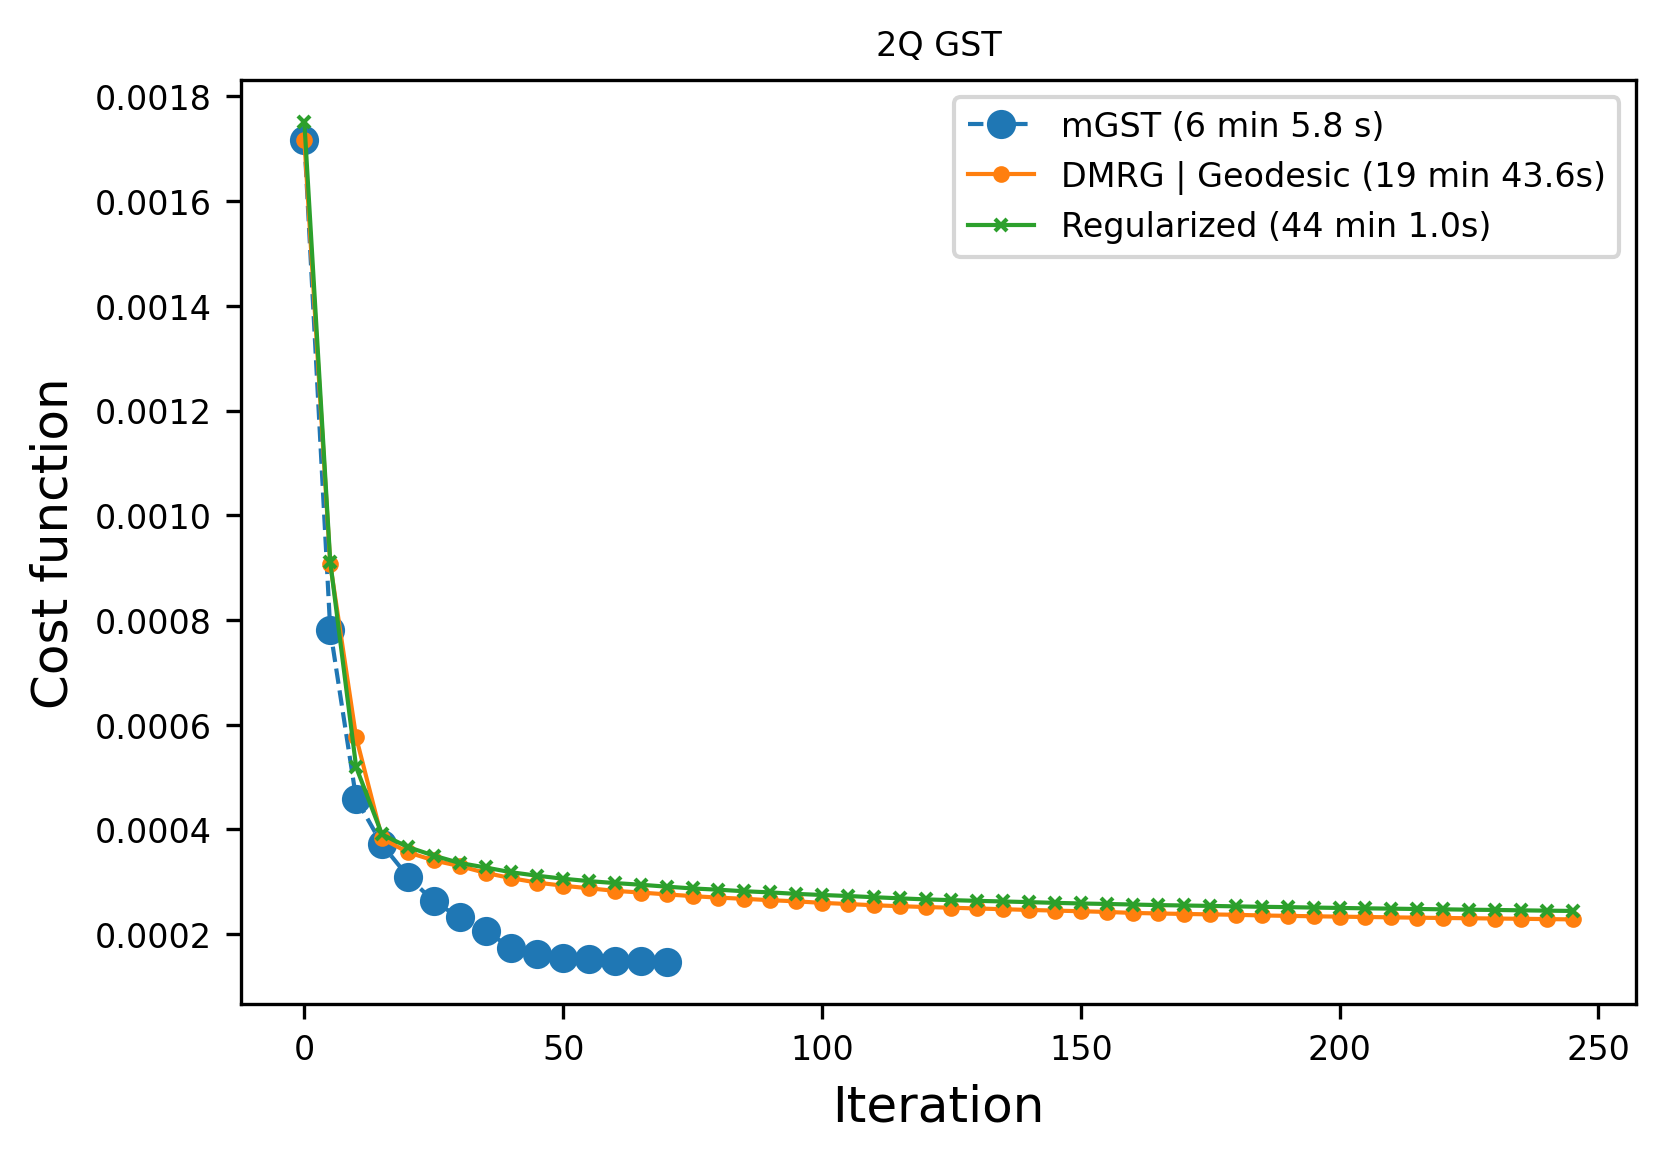

In [335]:
plot_step = 5

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(0,len(cost_fn_history_2q_mgst), plot_step), cost_fn_history_2q_mgst[::plot_step], "--o", linewidth=1, markersize=6, label="mGST (6 min 5.8 s)")
plt.plot(range(0, len(cost_fn_history_2q_dmrg_geo), plot_step), cost_fn_history_2q_dmrg_geo[::plot_step], marker="o", linestyle="-", linewidth=1, markersize=3, label="DMRG | Geodesic (19 min 43.6s)")
plt.plot(range(0, len(cost_fn_history_2q_regularized), plot_step), cost_fn_history_2q_regularized[::plot_step], marker="x", linestyle="-", linewidth=1, markersize=3, label="Regularized (44 min 1.0s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [336]:
cost_fn_history_2q_regularized[-1], cost_fn_history_2q_mgst[-1]

(Array(0.00024399, dtype=float64), Array(0.00014661, dtype=float64))

# 4Q GST

## Setup

In [5]:
Q4_GST = create_4q_gst_config()

K_4q, X_4q, E_4q, rho_4q, y_4q, J_4q, l_4q, depth_4q, pdim_4q, dim_squared_4q, n_povm_4q, bsize_4q, meas_samples_4q, n_4q, nt_4q, rK_4q = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, seed=42
)

2025-03-25 01:08:29,002 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-03-25 01:08:29,789 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-03-25 01:08:29,789 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-03-25 01:08:33,113 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-03-25 01:08:33,116 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-03-25 01:08:33,170 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [35]:
# creating the parameters needed for the jax version
num_povm_4q = E_4q.shape[0]
dim_4q = int(jnp.sqrt(E_4q.shape[1]))

povm_tensor_4q = jnp.reshape(E_4q, shape=(num_povm_4q, dim_4q, dim_4q))
state_4q = jnp.reshape(rho, shape=(dim_4q, dim_4q))

indices_list_4q = [indices[indices != -1] for indices in J_4q]

kraus_tensor_4q = K_4q
prob_matrix_4q = y_4q

state_psd_4q_rank_1 = factorize_psd_truncated(psd=state_4q, max_rank=1)
povm_psd_4q_rank_1  = factorize_psd_truncated(psd=povm_tensor_4q, max_rank=1).transpose(0, 2, 1)

jnp.allclose(state_psd_4q_rank_1 @ state_psd_4q_rank_1.conj().T, state), jnp.allclose(povm_psd_4q_rank_1.conj().transpose(0, 2, 1) @ povm_psd_4q_rank_1, povm_tensor_4q)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [38]:
state_psd_4q= factorize_psd_truncated(psd=state_4q, max_rank=dim_4q)
povm_psd_4q  = factorize_psd_truncated(psd=povm_tensor_4q, max_rank=dim_4q).transpose(0, 2, 1)

jnp.allclose(state_psd_4q @ state_psd_4q.conj().T, state), jnp.allclose(povm_psd_4q.conj().transpose(0, 2, 1) @ povm_psd_4q, povm_tensor_4q)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [39]:
state_psd_4q_rank_1.shape, state_psd_4q.shape

((16, 1), (16, 16))

## Optimization

In [40]:
kraus_updated_4q_dmrg_geo_rank1, povm_updated_4q_dmrg_geo_rank1, state_updated_4q_dmrg_geo_rank1, cost_fn_history_4q_dmrg_geo_rank1 = run_gds_jax(kraus_tensor=kraus_tensor_4q, povm_psd=povm_psd_4q_rank_1, state_psd=state_psd_4q_rank_1, indices_list=indices_list_4q, prob_matrix=prob_matrix_4q, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, ls_max_iter=30, use_geodesic=True, dmrg_like=True)

iteration:  0
Initial count: 30
at iteration 0 the new count changed to: 31
at iteration 1 the new count changed to: 32
at iteration 10 the new count changed to: 33
at iteration 91 the new count changed to: 34
at iteration 242 the new count changed to: 35
at iteration 393 the new count changed to: 36
at iteration 544 the new count changed to: 37
at iteration 696 the new count changed to: 38
at iteration 848 the new count changed to: 39
at iteration 1000 the new count changed to: 40
at iteration 1166 the new count changed to: 41
at iteration 1332 the new count changed to: 42
at iteration 1499 the new count changed to: 43
at iteration 1666 the new count changed to: 44
at iteration 1833 the new count changed to: 45
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial co

In [18]:
kraus_updated_4q_dmrg_geo, povm_updated_4q_dmrg_geo, state_updated_4q_dmrg_geo, cost_fn_history_4q_dmrg_geo = run_gds_jax(kraus_tensor=kraus_tensor_4q, povm_psd=povm_psd_4q, state_psd=state_psd_4q, indices_list=indices_list_4q, prob_matrix=prob_matrix_4q, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, ls_max_iter=30, use_geodesic=True, dmrg_like=True)

iteration:  0
Initial count: 30
Using JAX power
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Optimized step size for Povm: [29.00000001]
Using JAX power
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial co

In [41]:
# new time with 30 line search iterations
time_total_ls_30_rank16_test = 21*60 + 10
time_per_iteration_test = time_total_ls_30_rank16_test / 47

time_total_ls_30_rank16 = 59*60 + 59.1
time_per_iteration_ls_30_rank16 = time_total_ls_30_rank16 / len(cost_fn_history_4q_dmrg_geo)

time_total_ls_30_rank1 = 43*60 +52.4
time_per_iteration_ls_30_rank1 = time_total_ls_30_rank1 / len(cost_fn_history_4q_dmrg_geo_rank1)

time_per_iteration_ls_30_rank16, time_per_iteration_ls_30_rank1

(39.55054945054945, 29.24888888888889)

In [9]:
cost_data = [
    0.0006284817403657988,
    0.000597964396842685,
    0.0005584407289090529,
    0.0005233073324970568,
    0.0004943130904538842,
    0.0004714587706404248,
    0.00045354016572976335,
    0.00043875995897513866,
    0.00042550642011488497,
    0.0004129805825742401,
    0.0004015361735334209,
    0.00039174035801980983,
    0.0003833515655119709,
    0.00037602367268301635,
    0.00036964193494017127,
    0.0003641164569615683,
    0.0003593651229138515,
    0.00035525783649746184,
    0.0003517193537364459,
    0.00034905842813152217,
    0.00034621262964678153,
    0.00034342472718718194,
    0.0003427108948658096,
    0.00033907261717042473,
    0.00033671870292646027,
    0.00033437681227394076,
    0.00033252986491236035,
    0.00033100076993635113,
    0.0003299253274595753,
    0.00032988876737921873,
    0.00033179787292484037,
    0.00033707297263606273,
    0.0003455168338380298,
    0.0003540345982199688,
]

len(cost_data)

34

In [16]:
cost_data_2 = [
    0.0003569209711230523,
    0.0003504651103858799,
    0.00033888538095200267,
    0.0003289835032781738,
    0.0003234348598738212,
    0.00032130296204793847,
    0.00032053995129972476,
    0.0003200420810671231,
    0.000319573079208193,
    0.00031910457698193056,
    0.00031863104920295166,
    0.00031815390030488815,
    0.0003176740566616158,
]
data = cost_data + cost_data_2
len(data)

47

Final cost/Initial cost: 0.4918963403882043


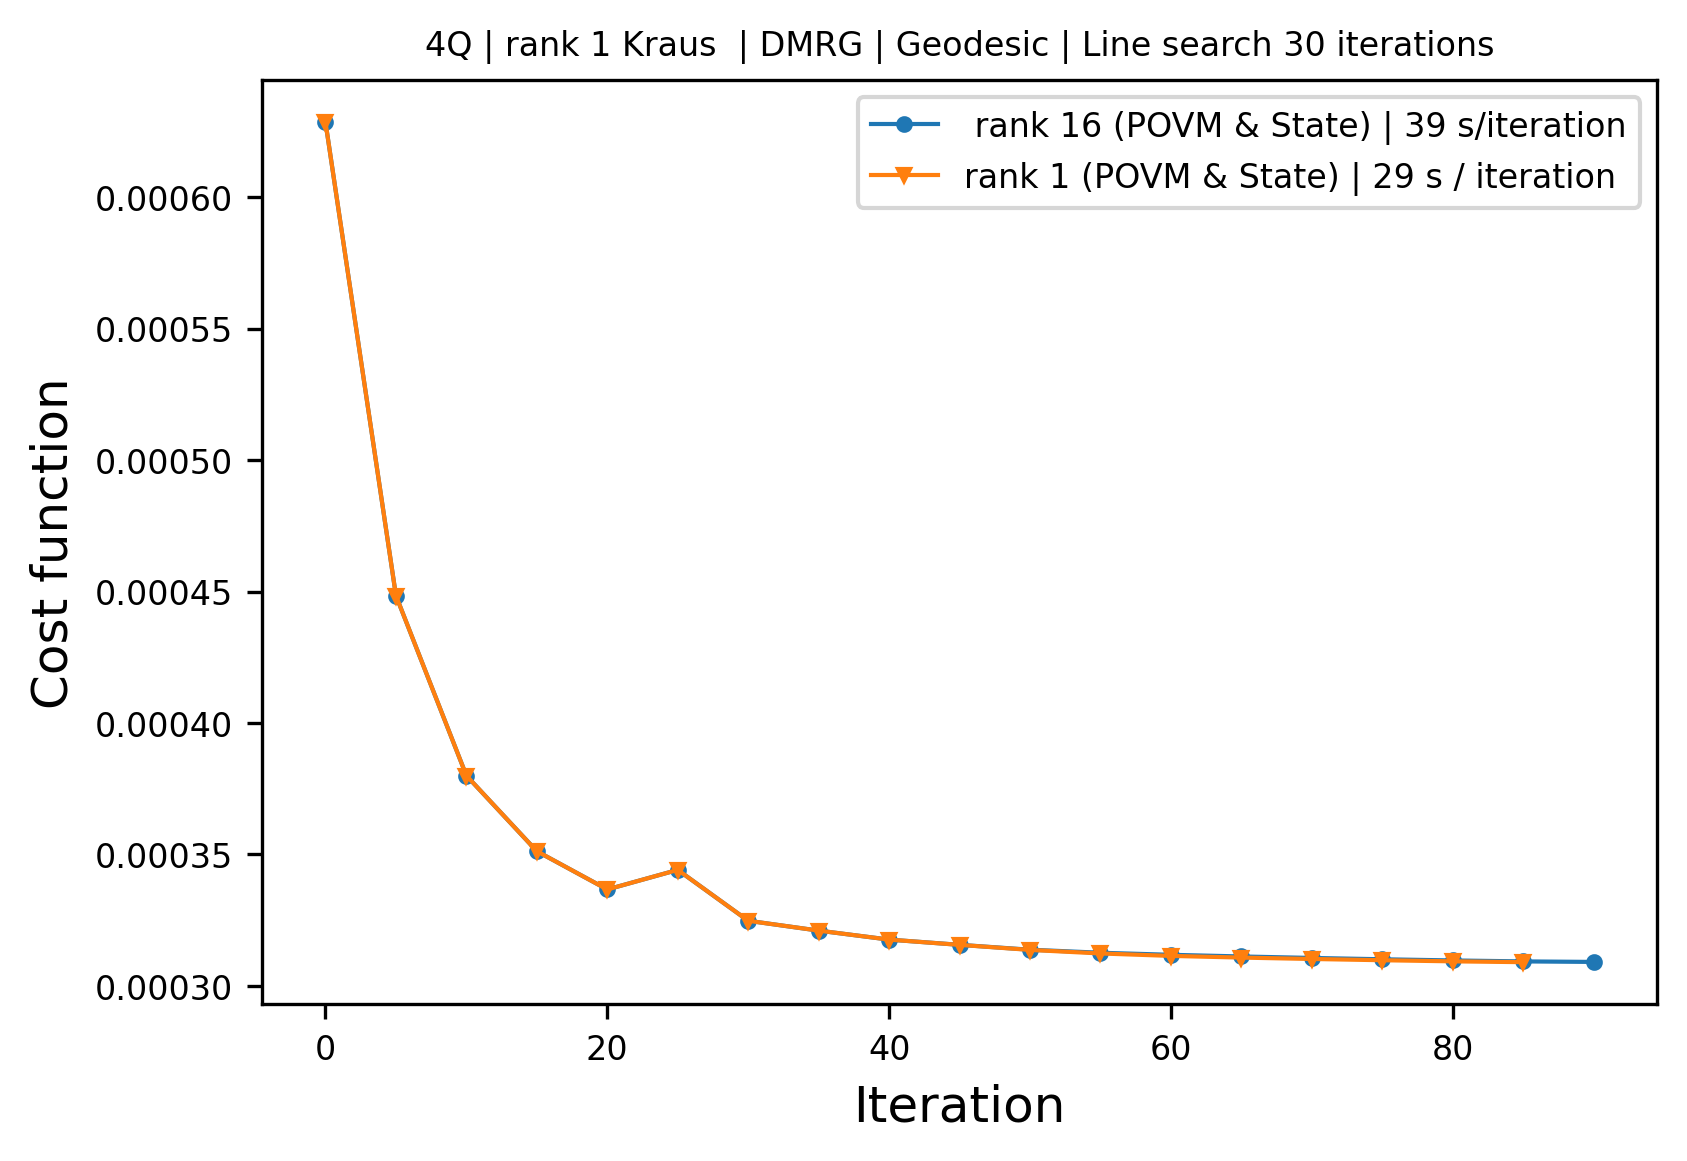

In [44]:
plot_step = 5

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(0, len(cost_fn_history_4q_dmrg_geo), plot_step), cost_fn_history_4q_dmrg_geo[::plot_step], marker="o", linestyle="-", linewidth=1, markersize=3, label=" rank 16 (POVM & State) | 39 s/iteration")
plt.plot(range(0, len(cost_fn_history_4q_dmrg_geo_rank1), plot_step), cost_fn_history_4q_dmrg_geo_rank1[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="rank 1 (POVM & State) | 29 s / iteration")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"4Q | rank 1 Kraus  | DMRG | Geodesic | Line search 30 iterations")
plt.ylabel("Cost function", fontsize=12)
plt.legend()
print(f"Final cost/Initial cost: {cost_fn_history_4q_dmrg_geo[-1]/cost_fn_history_4q_dmrg_geo[0]}")

## Performance comparison between frobenius and fidelity in terms of sqrt

In [ ]:
from mGST.low_level_jit import (
    frobenius_distance_expanded,
    frobenius_distance,
    state_fidelity,
    process_fidelity,
    process_fidelity_povm,
    )

In [28]:
# comparing against Frobenius norm
def _state_distance_frobenius(state_psd_est, state_psd_target, numpy:bool=False):
    "tensors are expected to be of dimensions (dim_out, rank_state)"
    state_estimate = state_psd_est @ state_psd_est.conj().T
    state_target = state_psd_target @ state_psd_target.conj().T
    if numpy:
        return frobenius_distance(state_estimate, state_target)
    return frobenius_distance_expanded(state_estimate, state_target)

def _povm_distance_frobenius(povm_psd_est, povm_psd_target, numpy:bool=False):
    "Tensors are expected to be of dimensions (num_povm, rank_povm, dim_in)"
    num_povm = povm_psd_est.shape[0]
    povm_estimate = povm_psd_est.conj().transpose(0, 2, 1) @ povm_psd_est
    povm_target = povm_psd_target.conj().transpose(0, 2, 1) @ povm_psd_target
    
    if numpy:
        metric_function = frobenius_distance
    else:
        metric_function = frobenius_distance_expanded
    
    regularized_value = 0
    for op_estimate, op_target in zip(povm_estimate, povm_target):
        regularized_value += metric_function(op_estimate, op_target)
    return regularized_value * 0.5 / num_povm

def _kraus_distance_frobenius(kraus_tensor_est, kraus_tensor_target, numpy:bool=False):
    "Tensors are expected to be of dimensions (num_gates, kraus_rank, dim_out, dim_in)"
    num_gates, _, dim_out, dim_in = kraus_tensor_est.shape
    kraus_estimate = jnp.einsum("ijkl, ijnm -> iknlm", kraus_tensor_est, kraus_tensor_est.conj()).reshape((num_gates, dim_out**2, dim_in**2))
    kraus_target = jnp.einsum("ijkl, ijnm -> iknlm", kraus_tensor_target, kraus_tensor_target.conj()).reshape((num_gates, dim_out**2, dim_in**2))
    
    if numpy:
        metric_function = frobenius_distance
    else:
        metric_function = frobenius_distance_expanded
    
    regularized_value = 0
    for op_estimate, op_target in zip(kraus_estimate, kraus_target):
        regularized_value += metric_function(op_estimate, op_target)
    return regularized_value * 0.5 / dim_in ** 2

In [31]:
state_updated_4q_dmrg_geo.shape, state_psd_4q.shape

((16, 16), (16, 16))

#### State

In [45]:
%timeit _state_distance_frobenius(state_updated_4q_dmrg_geo, state_psd_4q)

253 μs ± 34.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [46]:
%timeit _state_distance_frobenius(state_updated_4q_dmrg_geo, state_psd_4q, numpy=True)

153 μs ± 75.2 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [50]:
%timeit state_fidelity(state_updated_4q_dmrg_geo, state_psd_4q)

66.8 μs ± 3.79 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [83]:
1 - state_fidelity(state_updated_4q_dmrg_geo, state_psd_4q), _state_distance_frobenius(state_updated_4q_dmrg_geo, state_psd_4q)

(Array(0.02277567, dtype=float64), Array(0.04562488, dtype=float64))

#### POVM

In [51]:
%timeit _povm_distance_frobenius(povm_updated_4q_dmrg_geo, povm_psd_4q)

3.43 ms ± 184 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [52]:
%timeit _povm_distance_frobenius(povm_updated_4q_dmrg_geo, povm_psd_4q, numpy=True)

920 μs ± 6.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [53]:
%timeit entanglement_fidelity_povm(povm_updated_4q_dmrg_geo, povm_psd_4q)

113 μs ± 4.43 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
idx = 0
process_fidelity_povm(povm_psd_4q[idx], povm_psd_4q[idx]),  _povm_distance_frobenius(povm_updated_4q_dmrg_geo, povm_psd_4q)

(Array(1.+0.j, dtype=complex128), Array(0.01327106, dtype=float64))

In [99]:
num_povm_4q, dim_4q

(16, 16)

#### Kraus

In [54]:
%timeit _kraus_distance_frobenius(kraus_updated_4q_dmrg_geo, kraus_tensor_4q)

45.1 ms ± 1.69 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [55]:
%timeit _kraus_distance_frobenius(kraus_updated_4q_dmrg_geo, kraus_tensor_4q, numpy=True)

3.9 ms ± 211 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [56]:
%timeit entanglement_fidelity(kraus_updated_4q_dmrg_geo, kraus_tensor_4q)

114 μs ± 7.88 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
num_gates = kraus_tensor_4q.shape[0]
idx = -1
process_fidelity(kraus_tensor_4q[idx], kraus_tensor_4q[idx]) / (dim_4q**2)

Array(1.+0.j, dtype=complex128)

In [ ]:
(process_fidelity(kraus_updated_4q_dmrg_geo, kraus_updated_4q_dmrg_geo) / (dim_4q**2)).real

Array(9.00008001, dtype=float64)

In [108]:
_kraus_distance_frobenius(kraus_updated_4q_dmrg_geo, kraus_tensor_4q)

Array(0.06273905, dtype=float64)

## Optimization with regularization

In [118]:
from iqm.benchmarks.compressive_gst.compressive_gst import CompressiveGST
from mGST.qiskit_interface import qiskit_gate_to_operator

# target get sets for regularization
benchmark_4q = CompressiveGST(backend, Q4_GST)
gate_set_4q = benchmark_4q.gate_set
kraus_tensor_target_4q = qiskit_gate_to_operator(gate_set_4q)
kraus_tensor_target_4q.shape, povm_psd_4q_rank_1.shape, state_psd_4q_rank_1.shape


((9, 1, 16, 16), (16, 1, 16), (16, 1))

In [124]:
target_operators = [kraus_tensor_target_4q, povm_psd_4q_rank_1, state_psd_4q_rank_1]

kraus_updated_4q_regularized_rank1, povm_updated_4q_regularized_rank1, state_updated_4q_regularized_rank1, cost_fn_history_4q_regularized_rank1 = run_gds_jax(
    kraus_tensor=kraus_tensor_4q,
    povm_psd=povm_psd_4q_rank_1,
    state_psd=state_psd_4q_rank_1,
    indices_list=indices_list_4q,
    prob_matrix=prob_matrix_4q,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True,
    use_geodesic=True, dmrg_like=True, ls_max_iter=30,
    regularized=True,
    target_operators=target_operators, num_samples=meas_samples_4q)

iteration:  0
Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15


In [125]:
total_time_regularized_4q = 15*60 + 50.1
total_time_regularized_4q/len(cost_fn_history_4q_regularized_rank1)

28.790909090909093

Final cost/Initial cost: 0.47204306212016384


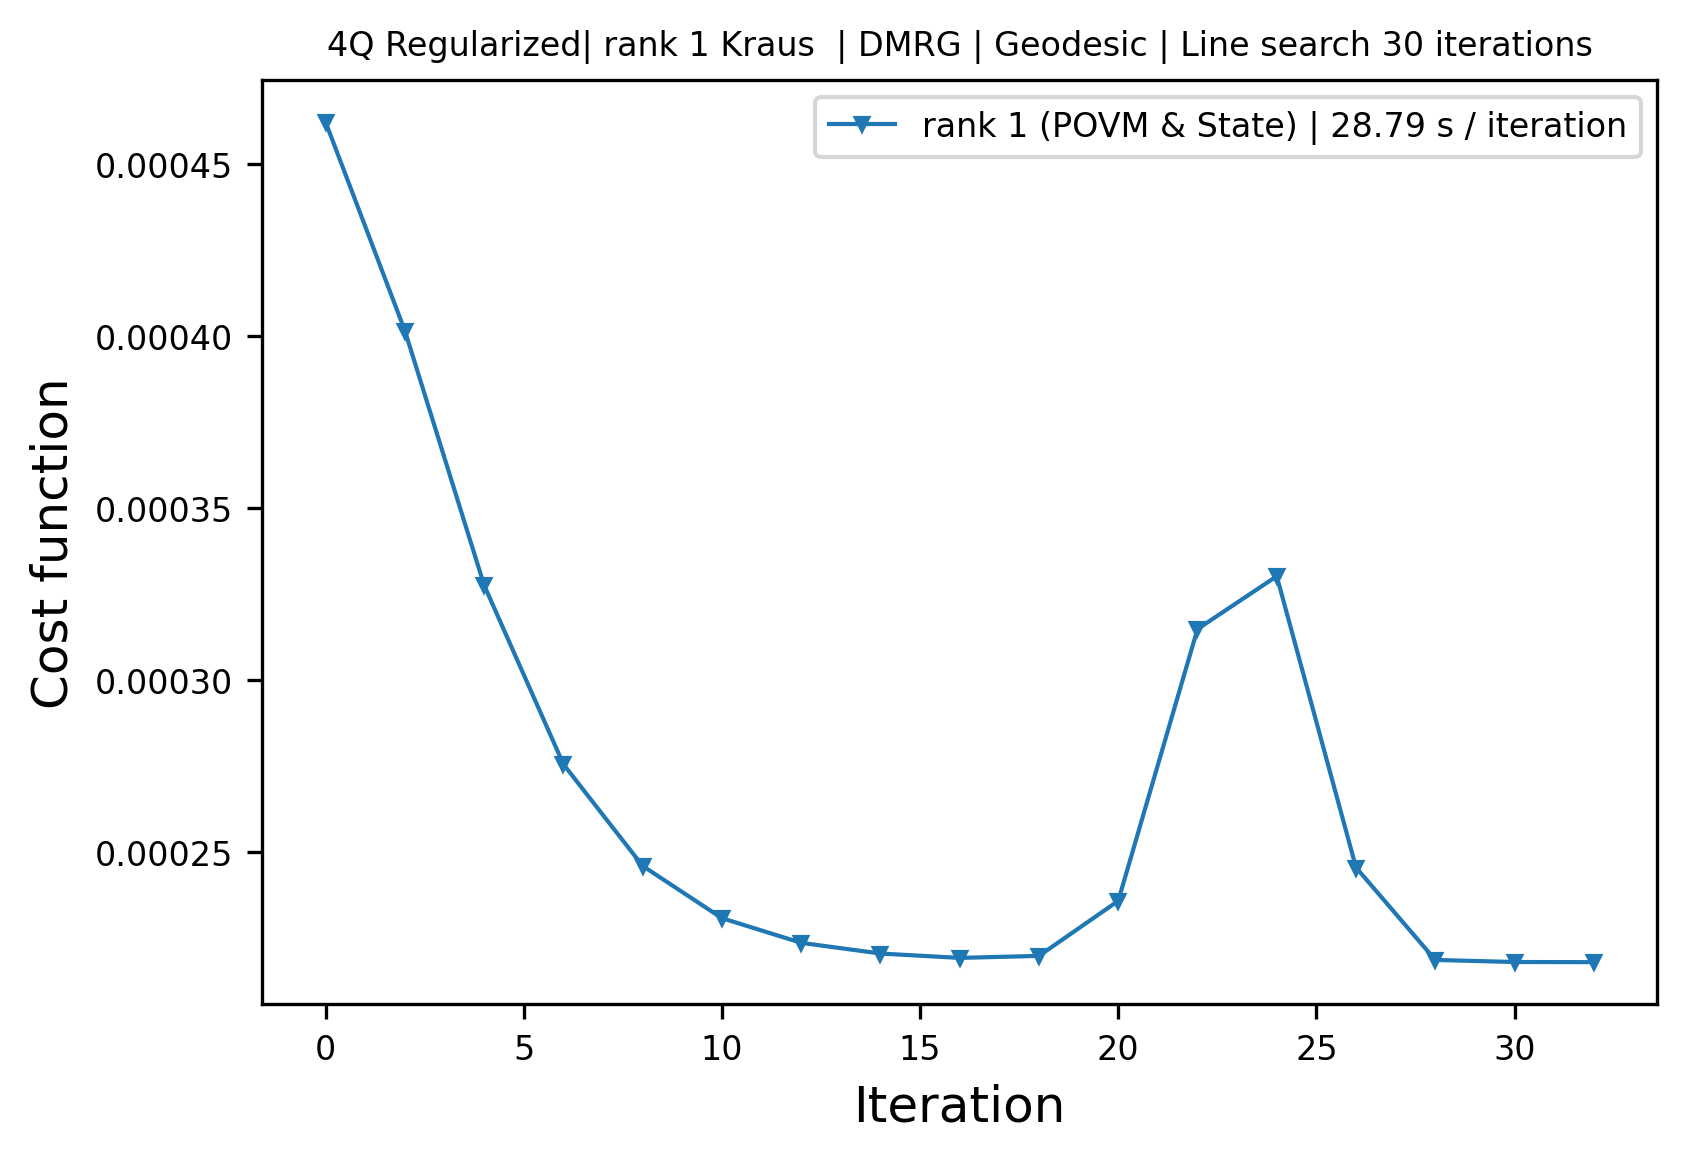

In [126]:
plot_step = 2
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(0, len(cost_fn_history_4q_regularized_rank1), plot_step), cost_fn_history_4q_regularized_rank1[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="rank 1 (POVM & State) | 28.79 s / iteration")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"4Q Regularized| rank 1 Kraus  | DMRG | Geodesic | Line search 30 iterations")
plt.ylabel("Cost function", fontsize=12)
plt.legend()
print(f"Final cost/Initial cost: {cost_fn_history_4q_regularized_rank1[-1]/cost_fn_history_4q_regularized_rank1[0]}")

# 2Q-Emerald comparison

## Setup

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CZGate, RGate

qubit_layouts = [[2,8], [4,10], [6,12], [15,23], [19,25], [21,27], [31,39], [30,35], [42,46], [44,48]]

gates = [QuantumCircuit(2, 0) for _ in range(7)]
gates[0].append(RGate(1e-9, 0), [0])
gates[1].append(RGate(0.5 * np.pi, 0), [0])
gates[2].append(RGate(0.5 * np.pi, 0), [1])
gates[3].append(RGate(0.5 * np.pi, np.pi / 2), [0])
gates[4].append(RGate(0.5 * np.pi, np.pi / 2), [1])
gates[5].append(RGate(0.5 * np.pi, 0), [0])
gates[5].append(RGate(0.5 * np.pi, 0), [1])
gates[6].append(CZGate(), [[0], [1]])
gate_labels = [
    "Idle",
    "Rx(pi/2):0",
    "Rx(pi/2):1",
    "Ry(pi/2):0",
    "Ry(pi/2):1",
    "Rx(pi/2)-Rx(pi/2):0-1",
    "CZ",
]

Q2_GST_EMERALD = GSTConfiguration(
    qubit_layouts=qubit_layouts,
    gate_set=gates,
    gate_labels = gate_labels,
    num_circuits=1000,
    shots=1000,
    rank=16,
    opt_method="GD",
    max_iterations = [140, 250],
    convergence_criteria=[4, 1e-4],
    parallel_execution = True,
    max_gates_per_batch = 35000
)

In [ ]:
Q2_GST_EMERALD.batch_size

'auto'

In [180]:
bsize = 30 * dim
bsize

120

In [3]:
import pickle

with open('emerald_2q_parallel_qubits_44__48.pkl', 'rb') as f:
    data = pickle.load(f)

In [4]:
data.keys()

dict_keys(['X_true', 'E_true', 'rho_true', 'K_target', 'X_target', 'E_target', 'rho_target'])

In [5]:
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

In [6]:
E_true.shape, X_true.shape, rho_true.shape

((4, 4, 4), (7, 16, 16), (4, 4))

In [7]:
E_target.shape, X_target.shape, rho_target.shape, K_target.shape

((4, 16), (7, 16, 16), (16,), (7, 1, 4, 4))

In [8]:
jnp.linalg.matrix_rank(rho_true), jnp.linalg.matrix_rank(E_true)

INFO:2025-04-03 18:27:20,546:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-04-03 18:27:20,546 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-04-03 18:27:20,549:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

(Array(3, dtype=int64), Array([3, 3, 3, 2], dtype=int64))

In [9]:
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]

state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [10]:
from mGST.additional_fns import sampled_measurements, random_seq_design
from mGST.low_level_jit import contract_mps_all_povm
import numpy as np


shots = 1000
num_gates = 7
n_povm = 4

N = 100  # Number of sequences
N_short = int(np.ceil(N / 2))
N_long = int(np.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences


# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots).copy()
prob_matrix_2q_sampled.shape

(4, 100)

In [171]:
# compute outcome probabilities
from mGST.low_level_jit import contract
E_true_test = E_true.reshape(num_povm, -1)
rho_true_test = rho_true.reshape(-1)
y_test = np.real(np.array([[E_true_test[i].conj() @ contract(X_true, j) @ rho_true_test for j in J]
            for i in range(n_povm)]))   # obtain ideal output probabilities

y_sampled_test = sampled_measurements(y_test, shots).copy()

jnp.allclose(y_sampled_test, prob_matrix_2q_sampled), jnp.allclose(y_test, prob_matrix_exact)

(Array(False, dtype=bool), Array(True, dtype=bool))

In [172]:
# idx_povm = 1
idx_list = 3
povm_idx_fix = jnp.array([E_true_test[idx_povm].conj() @ contract(X_true, J[idx_list]) @ rho_true_test for idx_povm in range(num_povm)])

povm_idx_fix_jax = contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices_list_2q[idx_list])
jnp.allclose(povm_idx_fix, povm_idx_fix_jax)

Array(True, dtype=bool)

In [173]:
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target  = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(n_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

## optimization

In [321]:
target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

kraus_updated_2q_regularized_full_rank, povm_updated_2q_regularized_full_rank, state_updated_2q_regularized_full_rank, cost_fn_history_2q_regularized_full_rank = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_target,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True,
    use_geodesic=True, dmrg_like=True, ls_max_iter=30,
    regularized=True,
    target_operators=target_operators, num_samples=shots,
    return_operators_list=True)

iteration:  0
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Optimized step size for Povm: [29.00000001]
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initia

In [274]:
total_time_ls_100 = 49.8
time_per_iteration_ls_100 = total_time_ls_100 / len(cost_fn_history_2q_regularized_full_rank_100ls)

total_time_ls_30 =  1 * 60 + 3.5
time_per_iteration_ls_30 = total_time_ls_30 / len(cost_fn_history_2q_regularized_full_rank)
time_per_iteration_ls_100, time_per_iteration_ls_30

(1.4228571428571428, 1.1140350877192982)

In [411]:
bsize, shots, 30 * 2 * 4, K_target.shape, num_gates, rho_target.shape, E_target.shape

(480, 1000, 240, (7, 1, 4, 4), 7, (16,), (4, 16))

In [425]:
K_target.shape, E_true.shape, rho_true.shape, prob_matrix_2q_sampled.shape, J.shape

((7, 1, 4, 4), (4, 4, 4), (4, 4), (4, 100), (100, 14))

In [169]:
from mGST.low_level_jit import dK
from mGST.additional_fns import perturbed_target_init

rank = 16
K_init_mgst = perturbed_target_init(X_target, rank, seed=42)
X_init_mgst = np.einsum("ijkl,ijnm -> iknlm", K_init_mgst, K_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
E_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)

_ = dK(X=X_init_mgst, K=K_init_mgst, E=E_target_mgst, rho=rho_target_mgst, J=J, y=prob_matrix_2q_sampled, d=num_gates, r=dim**2, rK=16)

In [181]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    prob_matrix_2q_sampled, indices_list_2q, 0, num_gates, dim**2, 16, num_povm, bsize, shots,
    init = [K_init_mgst, E_target_mgst, rho_target_mgst],
    method = "GD",
    max_iter=250,
    target_rel_prec=1e-4,
)

Starting mGST optimization...
100%|██████████| 70/70 [01:39<00:00,  1.43s/it]
	 Convergence criterion satisfied
	 Final objective 5.7829176485343556e-05 in time 100.05s


In [183]:
from mGST.low_level_jit import cost_function_jax_mps_regularized
cost_value_numba_2q_init = cost_function_numba(K_target, E_target_mgst, rho_target_mgst, J, prob_matrix_2q_sampled)

# shoudl use the processed indices, not J!
cost_value_jax_mgst_2q_init = cost_function_jax(
    X_init_mgst, E_target_mgst, rho_target_mgst, indices_list_2q, prob_matrix_2q_sampled,
)

cost_value_jax_2q_init =  cost_function_jax_mps_regularized(
            kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled,
            kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target, shots,
            jit=True)

cost_value_numba_2q_init, cost_value_jax_2q_init, cost_value_jax_mgst_2q_init, jnp.allclose(cost_value_numba_2q_init, cost_value_jax_2q_init * 2), jnp.allclose(cost_value_numba_2q_init, cost_value_jax_mgst_2q_init)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


(0.0034640100008150355,
 Array(0.00173201, dtype=float64),
 Array(0.00313047, dtype=float64),
 Array(True, dtype=bool),
 Array(False, dtype=bool))

In [ ]:
# jnp.allclose(cost_fn_history_2q_regularized_full_rank[0] * 2, cost_value_numba_2q_init)

Array(True, dtype=bool)

In [184]:
kraus_tensor_2q_init = jnp.array(K_init_mgst)

In [487]:
target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

kraus_updated_2q_regularized_perturbed_init, povm_updated_2q_regularized_perturbed_init, state_updated_2q_regularized_perturbed_init, cost_fn_history_2q_regularized_perturbed_init = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True,
    use_geodesic=True, dmrg_like=True, ls_max_iter=30,
    regularized=True,
    target_operators=target_operators, num_samples=shots,
    return_operators_list=True)

iteration:  0
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Optimized step size for Povm: [29.00000001]
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initia

In [185]:
target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]
# previous time: 7 min 43.1s
kraus_updated_2q_unregularized_perturbed_init, povm_updated_2q_unregularized_perturbed_init, state_updated_2q_unregularized_perturbed_init, cost_fn_history_2q_unregularized_perturbed_init = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True,
    use_geodesic=True, dmrg_like=True, ls_max_iter=30,
    regularized=False,
    return_operators_list=True)

iteration:  0
Initial count: 15
Using JAX power
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Optimized step size for Povm: [25.50000001]
Using JAX power
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial co

In [186]:
target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]
# previous: 4min 8.7 s
kraus_updated_2q_regularized_full_rank_100ls_perturbed, povm_updated_2q_regularized_full_rank_100ls_perturbed, state_updated_2q_regularized_full_rank_100ls_perturbed, cost_fn_history_2q_regularized_full_rank_100ls_perturbed = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True,
    use_geodesic=True, dmrg_like=True, ls_max_iter=100,
    regularized=True,
    target_operators=target_operators, num_samples=shots,
    return_operators_list=True)

iteration:  0
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count:

## Plotting comparison

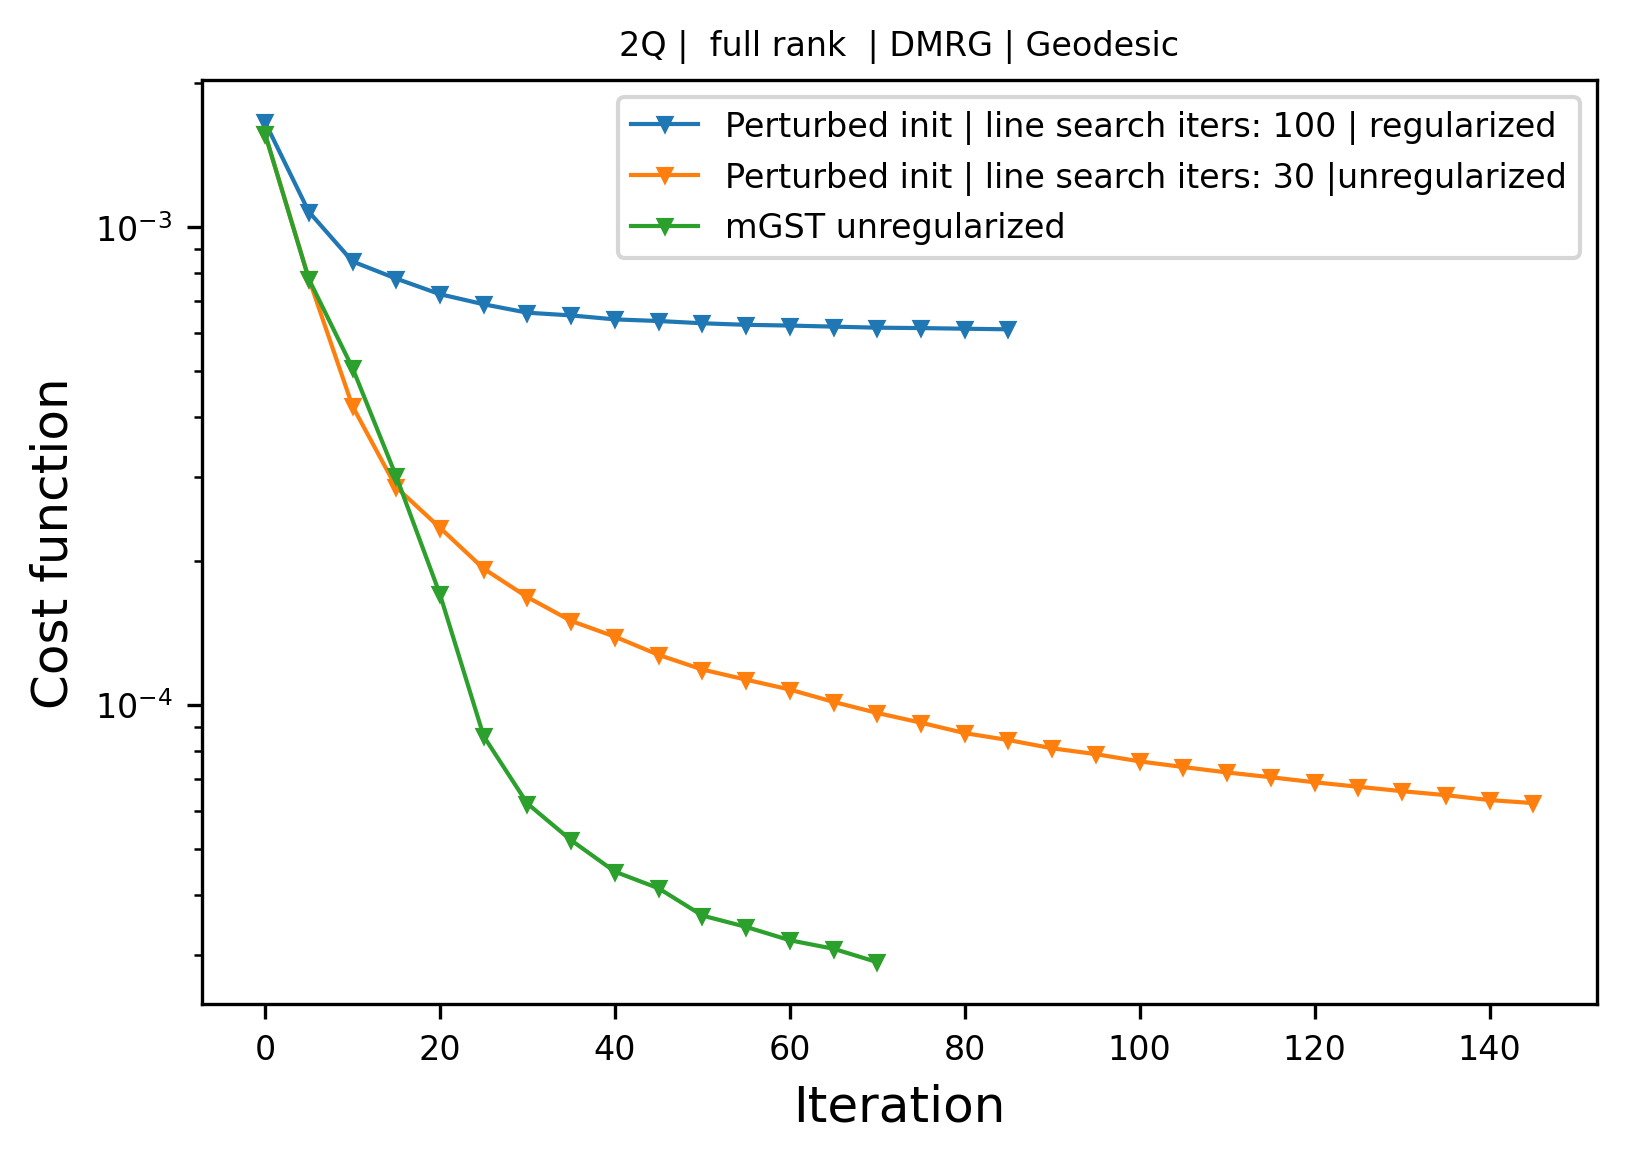

In [188]:
plot_step = 5
plt.figure(figsize=(6, 4), dpi=300)

# plt.semilogy(range(0, len(cost_fn_history_2q_regularized_full_rank), plot_step), cost_fn_history_2q_regularized_full_rank[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Unperturbed init | line search iters: 30 | regularized")

plt.semilogy(range(0, len(cost_fn_history_2q_regularized_full_rank_100ls_perturbed), plot_step), cost_fn_history_2q_regularized_full_rank_100ls_perturbed[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Perturbed init | line search iters: 100 | regularized")

# plt.semilogy(range(0, len(cost_fn_history_2q_regularized_perturbed_init), plot_step), cost_fn_history_2q_regularized_perturbed_init[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Perturbed init | line search iters: 30 | regularized")

cost_fn_history_2q_unregularized_perturbed_init_plot = jnp.array(cost_fn_history_2q_unregularized_perturbed_init) / 2

max_idx_data = 150
plt.semilogy(range(0, len(cost_fn_history_2q_unregularized_perturbed_init_plot[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_perturbed_init_plot[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Perturbed init | line search iters: 30 |unregularized")

cost_fn_history_2q_mgst_plot = jnp.array(cost_fn_history_2q_mgst)/2

plt.semilogy(range(0, len(cost_fn_history_2q_mgst_plot), plot_step), cost_fn_history_2q_mgst_plot[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="mGST unregularized")

# plt.semilogy(range(0, len(cost_fn_history_2q_regularized_full_rank_100ls), plot_step), cost_fn_history_2q_regularized_full_rank_100ls[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="line search iters: 100 |")

plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q |  full rank  | DMRG | Geodesic")
plt.ylabel("Cost function", fontsize=12)
plt.legend()
# print(f"Final cost/Initial cost: {cost_fn_history_2q_regularized_full_rank[-1]/cost_fn_history_2q_regularized_full_rank[0]}")

## Process fidelity (update from ent. fidelity for unital channels)

In [869]:
from mGST.low_level_jit import average_process_fidelity
kraus_updated_2q_regularized_full_rank[0].shape

(7, 16, 4, 4)

In [ ]:
superop_kraus_true = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))
idx = 3
jnp.trace(superop_kraus_true[idx].conj().T @ superop_kraus_true[idx]) / dim**2

In [ ]:
for idx in range(num_gates): 
    # ent_fidelity_kraus = entanglement_fidelity(kraus_tensor_2q_true[idx], kraus_tensor_2q_true[idx]) / dim**2
    ent_fidelity_kraus = jnp.trace(X_target[idx].conj().T @ X_target[idx])/ dim**2
    print((dim * ent_fidelity_kraus + 1) / (dim + 1), ent_fidelity_kraus)

In [1029]:
idx = 1
# kraus_tensor_target = kraus_updated_2q_regularized_full_rank[-1][idx]
# kraus_tensor_target = kraus_tensor_2q_true[idx]
kraus_tensor_target = kraus_tensor_2q_target[idx]
kraus_tensor_est = kraus_tensor_2q_true[idx]

jnp.einsum_path(
    "...ajk, ...bjm, ...alk, ...blm->", 
    kraus_tensor_target.conj(), kraus_tensor_est, 
    kraus_tensor_target, kraus_tensor_est.conj()
)

([(0, 2), (0, 1), (0, 1)],
   Complete contraction:  ajk,bjm,alk,blm->
          Naive scaling:  6
      Optimized scaling:  4
       Naive FLOP count:  2.621e+5
   Optimized FLOP count:  4.128e+3
    Theoretical speedup:  6.350e+1
   Largest intermediate:  1.600e+1 elements
 --------------------------------------------------------------------------------
 scaling        BLAS                current                             remaining
 --------------------------------------------------------------------------------
    4           TDOT            alk,ajk->lj                          bjm,blm,lj->
    4           TDOT            blm,bjm->lj                               lj,lj->
    2            DOT                lj,lj->                                    ->)

In [1030]:
for gate_idx in range(num_gates):
    kraus_test = kraus_tensor_2q_true[gate_idx]
    matrix_test = jnp.einsum("ijk, ijm -> km", kraus_test, kraus_test.conj())
    assert jnp.allclose(matrix_test, jnp.eye(dim))

In [1031]:
jnp.einsum(
    "...ajk, ...bjm, ...alk, ...blm->", 
    kraus_tensor_target.conj(), kraus_tensor_est, 
    kraus_tensor_target, kraus_tensor_est.conj()
)

Array(4.+6.06005649e-36j, dtype=complex128)

In [1032]:
jnp.einsum(
        "...ajk, ...bjk, ...alm, ...blm->", 
        kraus_tensor_target.conj(), kraus_tensor_est, 
        kraus_tensor_target, kraus_tensor_est.conj()
    )

Array(15.91357803+0.j, dtype=complex128)

In [1033]:
# Testing if the adjoint channel of the target is trace preserving
# Equivalent, testing it it's unital
test_matrix = jnp.einsum(
    "...ajk, ...alk-> jl", 
    kraus_tensor_target.conj(),kraus_tensor_target,
)
jnp.allclose(test_matrix, jnp.eye(dim))

Array(True, dtype=bool)

In [1034]:
# Testing if the composition of the adjoint of channel 1 and channel 2 is trace preserving
test_matrix = jnp.einsum(
    "...ajk, ...bjm, ...alk, ...bln->mn", 
    kraus_tensor_target.conj(), kraus_tensor_est, 
    kraus_tensor_target, kraus_tensor_est.conj()
)
jnp.allclose(test_matrix, jnp.eye(dim))

Array(True, dtype=bool)

In [1035]:
dim * (dim + 1), dim

(20, 4)

In [1036]:
process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=True) # entanglement fidelity assuming unitarity

Array(0.99459863, dtype=float64)

In [1037]:
process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=False) # process fidelity general

Array(0.99459863, dtype=float64)

In [1038]:
(dim**2 * process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=True) + dim)/(dim * (dim + 1)) # avg process fidelity assuming unitarity

Array(0.9956789, dtype=float64)

In [1039]:
average_process_fidelity(kraus_tensor_target, kraus_tensor_est, unital=False) # avg fidelity general

Array(0.9956789, dtype=float64)

In [1040]:
average_process_fidelity(kraus_tensor_target, kraus_tensor_est, unital=True) # avg fidelity unital (using fn)

Array(0.9956789, dtype=float64)

In [933]:
# can attempt to get the process fidelity using the general expression given in equation 3 of QCVV new paper.
rank_kraus = 16
choi_sqrt_est_test = kraus_tensor_est.reshape(rank_kraus, dim**2).T
choi_sqrt_target_test = kraus_tensor_target.reshape(rank_kraus, dim**2).T
state_fidelity(operator_sqrt_est=choi_sqrt_est_test, operator_sqrt_target=choi_sqrt_target_test) / dim**2

Array(0.99378359, dtype=float64)

In [934]:
choi_product = jnp.einsum("...roi, ...qoi -> ...rq", kraus_tensor_est.conj(), kraus_tensor_target)
jnp.linalg.norm(choi_product, ord="nuc", axis=(-2, -1)) **2 / dim**2

Array(0.99378359, dtype=float64)

In [1042]:
from mGST.low_level_jit import state_fidelity_from_density_matrices

choi_est_test = jnp.einsum(
    "ijk, imn-> jkmn", kraus_tensor_est, kraus_tensor_est.conj()
).reshape(dim**2, dim**2)

choi_target_test = jnp.einsum(
    "ijk, imn-> jkmn", kraus_tensor_target, kraus_tensor_target.conj()
).reshape(dim**2, dim**2)

state_fidelity_from_density_matrices(choi_est_test, choi_target_test).real / dim**2

Array(0.99459873, dtype=float64)

In [916]:
jnp.allclose(state_fidelity(operator_sqrt_est=choi_sqrt_est_test, operator_sqrt_target=choi_sqrt_target_test),
             state_fidelity_from_density_matrices(choi_est_test, choi_target_test).real)

Array(True, dtype=bool)

## Fidelity for POVM (general)

In [ ]:
from mGST.low_level_jit import process_fidelity_povm, state_fidelity_from_density_matrices

In [14]:
povm_psd_2q_true.shape, E_true.shape, E_target.shape

((4, 4, 4), (4, 4, 4), (4, 16))

In [15]:
# Completeness relation
jnp.allclose(jnp.sum(E_true, axis=0), jnp.eye(dim)), jnp.allclose(jnp.sum(E_target.reshape(num_povm, dim, dim), axis=0), jnp.eye(dim))

(Array(True, dtype=bool), Array(True, dtype=bool))

In [16]:
# This was supposedly testing if its unital,
# But I was expecting a matrix, so maybe this is not well defined without the full kraus tensors
test_matrix = jnp.einsum(
    "iaj, iaj->", 
    povm_psd_2q_true.conj() ,povm_psd_2q_true,
)
test_matrix

Array(4.+0.j, dtype=complex128)

In [17]:
# non traceless operators
jnp.trace(E_true, axis1=1, axis2=2) # it is not unital!

Array([1.10468598+0.j, 1.01991136+0.j, 0.98520691+0.j, 0.89019576+0.j],      dtype=complex128)

In [18]:
# trace of POVM's: as expected since these are orthogonal operators
jnp.trace(E_target.reshape(num_povm, dim, dim), axis1=1, axis2=2)

Array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j], dtype=complex128)

In [ ]:
# trace of POVM's
povm_test = povm_updated_2q_regularized_full_rank_100ls_perturbed[-1]
povm_opt_contracted = povm_test.conj().transpose(0, 2, 1) @ povm_test
jnp.trace(povm_opt_contracted, axis1=1, axis2=2)

Array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j], dtype=complex128)

In [ ]:
# completeness relation of POVM
jnp.allclose(jnp.sum(povm_opt_contracted, axis=0), jnp.eye(dim))

Array(True, dtype=bool)

In [19]:
# Testing if the composition of the adjoint of channel 1 and channel 2 is trace preserving
test_matrix = jnp.einsum(
    "iaj, ibm, iak, ibn->mn", 
    povm_psd_2q_true.conj(), povm_psd_2q_true, 
    povm_psd_2q_true, povm_psd_2q_true.conj()
)
jnp.allclose(test_matrix, jnp.eye(dim))

Array(False, dtype=bool)

In [ ]:
# This probably works because of orthogonality
process_fidelity_povm(povm_psd_2q_target, povm_psd_2q_target, unital=True)

Array(1., dtype=float64)

In [ ]:
process_fidelity_povm(povm_psd_2q_target, povm_psd_2q_target, unital=False)

Array(1., dtype=float64)

In [ ]:
process_fidelity_povm(povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], unital=True)

Array(1., dtype=float64)

In [ ]:
process_fidelity_povm(povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], unital=False)

Array(1., dtype=float64)

In [ ]:
process_fidelity_povm(povm_psd_2q_true, povm_psd_2q_true, unital=True)

Array(0.8893474, dtype=float64)

In [ ]:
process_fidelity_povm(povm_psd_2q_true, povm_psd_2q_true, unital=False)

Array(1., dtype=float64)

In [ ]:
process_fidelity_povm(povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], povm_psd_2q_true, unital=True)

Array(0.9394289, dtype=float64)

In [ ]:
process_fidelity_povm(povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], povm_psd_2q_true, unital=False)

Array(0.7466508, dtype=float64)

In [ ]:
process_fidelity_povm(povm_psd_2q_target, povm_psd_2q_true, unital=False)

Array(0.74665768, dtype=float64)

In [ ]:
process_fidelity_povm(povm_psd_2q_target, povm_psd_2q_true, unital=True)

Array(0.93976956, dtype=float64)

In [159]:
# povm_tensor_target = povm_updated_2q_regularized_full_rank_100ls_perturbed[-1]
povm_tensor_target = povm_psd_2q_target
povm_tensor_est = povm_psd_2q_true

choi_product = jnp.einsum("iaj, ibj -> iab", povm_tensor_target.conj(), povm_tensor_est)
# choi_product.shape
norms_i = jnp.linalg.norm(choi_product, ord="nuc", axis=(-2, -1))
sum(norms_i**2)/num_povm, sum(norms_i)**2/dim**2 # dim instead of POVM, because here we are normalizing the choi state

(Array(0.93976956, dtype=float64), Array(0.93924781, dtype=float64))

In [ ]:
# Testing to get the choi states and get the fidelity from those
povm_tensor_target = povm_psd_2q_target # num_povm, rank_povm, dim_in
povm_tensor_est = povm_psd_2q_true # num_povm, rank_povm, dim_in
# Get choi states

def computational_basis_state(x: int, dim:int) -> jnp.ndarray:
    """Returns the computational basis state |x⟩ in a Hilbert space of dimension dim."""
    return jnp.eye(dim)[x]

def get_superop_povm(povm_tensor:jnp.ndarray) -> jnp.ndarray:
    """Get the superoperator representation from the POVM tensor.
    
    Args:
        povm_tensor: The POVM tensor of shape (num_povm, rank_povm, dim_in).
    """
    dim = povm_tensor.shape[-1]
    basis_matrix = jnp.eye(dim) # dim, dim (real)
    return jnp.einsum(
        "ji,ikm,li,ikn->jlmn", basis_matrix, povm_tensor, basis_matrix, povm_tensor.conj()
    )
    
def get_choi_povm(povm_tensor:jnp.ndarray) -> jnp.ndarray:
    """Get the choi representation from the POVM tensor.
    """
    dim = povm_tensor.shape[-1]
    basis_matrix = jnp.eye(dim) # dim, dim (real)
    return jnp.einsum(
        "ji,ikm,li,ikn->jmln", basis_matrix, povm_tensor, basis_matrix, povm_tensor.conj()
    ) # is equivalent to swaping axes 1,2 from superoperator

superop_povm_target = get_superop_povm(povm_tensor_target)
# zero_state = computational_basis_state(0, dim)
# zero_matrix = jnp.outer(zero_state, zero_state.conj())
(jnp.einsum("jlmm-> jl", superop_povm_target), # unital
jnp.allclose(jnp.einsum("jjmn->mn", superop_povm_target), jnp.eye(dim))) # trace preserving

(Array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]], dtype=complex128),
 Array(True, dtype=bool))

In [102]:
choi_povm_target = get_choi_povm(povm_tensor_target)
jnp.allclose(choi_povm_target, superop_povm_target.swapaxes(1,2))

Array(True, dtype=bool)

In [ ]:
# Same tests but now for the estimated POVM
superop_povm_est = get_superop_povm(povm_tensor_est)
choi_povm_est = get_choi_povm(povm_tensor_est)
(jnp.allclose(choi_povm_est, superop_povm_est.swapaxes(1,2)), # sanity check
jnp.allclose(jnp.einsum("jjmn->mn", superop_povm_est), jnp.eye(dim)), # trace preserving
jnp.einsum("jlmm-> jl", superop_povm_est), # non-unital
)

(Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array([[1.10468598+0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j],
        [0.        +0.j, 1.01991136+0.j, 0.        +0.j, 0.        +0.j],
        [0.        +0.j, 0.        +0.j, 0.98520691+0.j, 0.        +0.j],
        [0.        +0.j, 0.        +0.j, 0.        +0.j, 0.89019576+0.j]],      dtype=complex128))

In [128]:
choi_povm_est_matrix = choi_povm_est.reshape(dim**2, dim**2)
choi_povm_target_matrix = choi_povm_target.reshape(dim**2, dim**2)

fidelity_from_states = state_fidelity_from_density_matrices(choi_povm_target_matrix, choi_povm_est_matrix).real / dim**2
fidelity_from_states

Array(0.93924781, dtype=float64)

In [129]:
jnp.allclose(fidelity_from_states, sum(norms_i)**2/num_povm**2)

Array(True, dtype=bool)

In [ ]:
# Check what are the Kraus operators of such choi matrix
from mGST.utility_functions_comparisons import factorize_psd_truncated
jnp.linalg.matrix_rank(choi_povm_est_matrix), choi_povm_est_matrix.shape

(Array(11, dtype=int64), (16, 16))

In [114]:
choi_povm_est_factor = factorize_psd_truncated(psd=choi_povm_est_matrix, max_rank=dim**2)
choi_povm_est_factor.shape


(16, 16)

In [ ]:
# I am going to try to construct the Choi factor
basis_stacked = jnp.eye(dim)
choi_factor_est = jnp.einsum(
    "ji, ikm -> jmik", basis_stacked, povm_tensor_est
) # dim_out, dim_in, num_povm, rank_povm
choi_factor_test_matrix = choi_factor_est.reshape(dim**2, num_povm * dim) # dim^2, dim^2
jnp.allclose(choi_factor_test_matrix, choi_povm_est_factor)

Array(False, dtype=bool)

In [145]:
# No? Do they produce the same choi state tho?
choi_state_test = choi_factor_test_matrix @ choi_factor_test_matrix.conj().T
jnp.allclose(choi_state_test, choi_povm_est_matrix) #it is TRUE!

Array(True, dtype=bool)

In [ ]:
# is the norm of this also true then:
choi_factor_target = jnp.einsum(
    "ji, ikm -> jmik", basis_stacked, povm_tensor_target
) # dim_out, dim_in, num_povm, rank_povm
choi_product_test = jnp.einsum("nmjs, nmik -> jsik", choi_factor_target.conj(), choi_factor_est)
rank_povm = dim
choi_product_test_matrix = choi_product_test.reshape(num_povm * rank_povm, num_povm * rank_povm)
fidelity_from_contraction_of_factors = jnp.linalg.norm(choi_product_test_matrix, ord="nuc") **2 / dim**2
fidelity_from_contraction_of_factors

Array(0.93924781, dtype=float64)

In [157]:
jnp.allclose(fidelity_from_states, fidelity_from_contraction_of_factors)

Array(True, dtype=bool)

In [139]:
print(E_target.shape)
jnp.linalg.matrix_rank(E_true), jnp.linalg.matrix_rank(E_target.reshape(num_povm, dim, dim)), 

(4, 16)


(Array([3, 3, 3, 2], dtype=int64), Array([1, 1, 1, 1], dtype=int64))

### Testing other options for fidelity of POVM

In [69]:
jnp.einsum(
    "iaj, ibj, iak, ibk->", 
    povm_tensor_target.conj(), povm_tensor_est, 
    povm_tensor_target, povm_tensor_est.conj()
)/num_povm

Array(0.93976956+0.j, dtype=complex128)

In [1012]:
povm_tensor_target = povm_psd_2q_true
povm_tensor_est = povm_updated_2q_regularized_full_rank_100ls_perturbed[-1]
jnp.einsum(
    "iaj, ibj, iak, ibk->", 
    povm_tensor_target.conj(), povm_tensor_est, 
    povm_tensor_target, povm_tensor_est.conj()
)/num_povm

Array(0.9394289+0.j, dtype=complex128)

In [ ]:
process_fidelity_povm(povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], povm_psd_2q_target, unital=True)

Array(0.99907225, dtype=float64)

In [ ]:
process_fidelity_povm(povm_updated_2q_regularized_full_rank_100ls_perturbed[-1], povm_psd_2q_target, unital=False)

Array(0.99907165, dtype=float64)

In [79]:
choi_product = jnp.einsum("ari, aqi -> rq", povm_psd_2q_true.conj(), povm_psd_2q_target)
jnp.linalg.norm(choi_product, ord="nuc") **2 / dim**2

Array(0.74665768, dtype=float64)

### Timing performance

In [167]:
def povm_fidelity_using_state_fidelity(povm_tensor_est, povm_tensor_target):
    """
    Computes the fidelity between two POVMs using the state fidelity formula.
    
    Args:
        povm_est: The estimated POVM tensor of shape (num_povm, rank_povm, dim_in).
        povm_target: The target POVM tensor of shape (num_povm, rank_povm, dim_in).
    
    Returns:
        The fidelity between the two POVMs.
    """
    dim = povm_tensor_est.shape[-1]
    choi_est = get_choi_povm(povm_tensor_est).reshape(dim**2, dim**2)
    choi_target = get_choi_povm(povm_tensor_target).reshape(dim**2, dim**2)
    return state_fidelity_from_density_matrices(choi_est, choi_target).real / dim**2

def povm_fidelity_from_block_matrices(povm_tensor_est, povm_tensor_target):
    """
    Computes the fidelity between two POVMs using the block matrix formula.
    
    Args:
        povm_est: The estimated POVM tensor of shape (num_povm, rank_povm, dim_in).
        povm_target: The target POVM tensor of shape (num_povm, rank_povm, dim_in).
    
    Returns:
        The fidelity between the two POVMs.
    """
    dim = povm_tensor_est.shape[-1]
    choi_product = jnp.einsum("iaj, ibj -> iab", povm_tensor_target.conj(), povm_tensor_est)
    # choi_product.shape
    norms_i = jnp.linalg.norm(choi_product, ord="nuc", axis=(-2, -1))
    return jnp.sum(norms_i)**2/dim**2

def povm_fidelity_from_full_choi_factors(povm_tensor_est, povm_tensor_target):
    """
    Computes the fidelity between two POVMs using the full Choi factors.
    
    Args:
        povm_est: The estimated POVM tensor of shape (num_povm, rank_povm, dim_in).
        povm_target: The target POVM tensor of shape (num_povm, rank_povm, dim_in).
    
    Returns:
        The fidelity between the two POVMs.
    """
    dim = povm_tensor_est.shape[-1]
    basis_stacked = jnp.eye(dim)
    choi_factor_est = jnp.einsum(
        "ji, ikm -> jmik", basis_stacked, povm_tensor_est
    )
    choi_factor_target = jnp.einsum(
        "ji, ikm -> jmik", basis_stacked, povm_tensor_target
        ) # dim_out, dim_in, num_povm, rank_povm
    # here it should actually be: rank_1*num_povm, rank_2*num_povm
    choi_product = jnp.einsum("nmjs, nmik -> jsik", choi_factor_target.conj(), choi_factor_est).reshape(dim**2, dim**2)
    return jnp.linalg.norm(choi_product, ord="nuc") **2 / dim**2

value_from_state = povm_fidelity_using_state_fidelity(povm_psd_2q_true, povm_psd_2q_target)
value_from_block = povm_fidelity_from_block_matrices(povm_psd_2q_true, povm_psd_2q_target)
value_from_contraction = povm_fidelity_from_full_choi_factors(povm_psd_2q_true, povm_psd_2q_target)

jnp.allclose(value_from_state, value_from_block), jnp.allclose(value_from_state, value_from_contraction), jnp.allclose(value_from_block, value_from_contraction)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [164]:
%timeit povm_fidelity_using_state_fidelity(povm_psd_2q_true, povm_psd_2q_target)

1.18 ms ± 106 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [168]:
%timeit povm_fidelity_from_block_matrices(povm_psd_2q_true, povm_psd_2q_target)

114 μs ± 516 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [166]:
%timeit povm_fidelity_from_full_choi_factors(povm_psd_2q_true, povm_psd_2q_target)

385 μs ± 5.36 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Test fidelity when one of them being pure 

In [1043]:
jnp.linalg.matrix_rank(choi_target_test)

Array(1, dtype=int64)

In [1046]:
idx = 1
kraus_tensor_target = kraus_tensor_2q_true[idx]
kraus_tensor_est = kraus_tensor_2q_true[idx]

choi_sqrt_target_test = kraus_tensor_target.reshape(rank_kraus, dim**2).T
choi_sqrt_target_test_rank1 = choi_sqrt_target_test[:, :1]

rank_kraus = 16
choi_sqrt_est_test = kraus_tensor_est.reshape(rank_kraus, dim**2).T

state_fidelity(operator_sqrt_est=choi_sqrt_est_test, operator_sqrt_target=choi_sqrt_target_test_rank1, pure=True)/ dim**2

Array(0.98964333, dtype=float64)

In [1047]:
process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=True) # entanglement fidelity assuming unitarity

Array(0.98964998, dtype=float64)

In [1048]:
process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=False) # entanglement fidelity assuming unitarity

Array(1., dtype=float64)

In [1050]:
%timeit process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=False) # entanglement fidelity assuming unitarity

418 μs ± 21.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [1051]:
%timeit process_fidelity(kraus_tensor_target, kraus_tensor_est, unitary=True) # entanglement fidelity assuming unitarity

489 μs ± 71.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [816]:
%timeit state_fidelity(operator_sqrt_est=choi_sqrt_est_test, operator_sqrt_target=choi_sqrt_target_test_rank1, pure=True) 
# using transpose and manual sum over squared norm of entries

146 μs ± 294 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [818]:
%timeit state_fidelity(operator_sqrt_est=choi_sqrt_est_test, operator_sqrt_target=choi_sqrt_target_test_rank1, pure=True) 
# using einsum instead of transpose and vdot instead of manual sum over squared norm of entries

299 μs ± 26.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [819]:
%timeit state_fidelity(operator_sqrt_est=choi_sqrt_est_test, operator_sqrt_target=choi_sqrt_target_test_rank1, pure=True)
# using transpose and vdot

125 μs ± 373 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## testing fidelities

In [919]:
kraus_updated_2q_regularized_full_rank_100ls_perturbed[0].shape

(7, 16, 4, 4)

In [189]:
state_psd_2q_target.shape

(4, 4)

In [219]:
from mGST.low_level_jit import process_fidelity, state_fidelity, process_fidelity_povm

kraus_tensor_fidelities_to_true = [process_fidelity(estimate, kraus_tensor_2q_true, unitary=False) for estimate in kraus_updated_2q_regularized_full_rank_100ls_perturbed]

kraus_tensor_fidelities_to_target = [process_fidelity(estimate, kraus_tensor_2q_target, unitary=True) for estimate in kraus_updated_2q_regularized_full_rank_100ls_perturbed]

state_fidelities_to_true = [state_fidelity(estimate, state_psd_2q_true, pure=False) for estimate in state_updated_2q_regularized_full_rank_100ls_perturbed]

state_fidelities_to_target = [state_fidelity(estimate, state_psd_2q_target, pure=True) for estimate in state_updated_2q_regularized_full_rank_100ls_perturbed]

povm_fidelities_to_true = [process_fidelity_povm(estimate, povm_psd_2q_true) for estimate in povm_updated_2q_regularized_full_rank_100ls_perturbed]

povm_fidelities_to_target = [process_fidelity_povm(estimate, povm_psd_2q_target) for estimate in povm_updated_2q_regularized_full_rank_100ls_perturbed]

In [230]:
# Testing if the implementation with
# operator_sqrt_target = operator_sqrt_target[:, 0:1] gives the same results
state_fidelities_to_target_test = [state_fidelity(estimate, state_psd_2q_target, pure=False) for estimate in state_updated_2q_regularized_full_rank_100ls_perturbed]
jnp.allclose(jnp.array(state_fidelities_to_target_test), jnp.array(state_fidelities_to_target))

Array(True, dtype=bool)

In [214]:
(process_fidelity(kraus_tensor_2q_true, kraus_tensor_2q_true, unitary=False) / num_gates,
 process_fidelity(kraus_tensor_2q_target, kraus_tensor_2q_target) / num_gates)

(Array(1., dtype=float64), Array(1., dtype=float64))

In [215]:
(process_fidelity_povm(povm_psd_2q_true, povm_psd_2q_true),
 process_fidelity_povm(povm_psd_2q_target, povm_psd_2q_target))

(Array(1., dtype=float64), Array(1., dtype=float64))

In [216]:
state_fidelity(state_psd_2q_true, state_psd_2q_true), state_fidelity(state_psd_2q_target, state_psd_2q_target)

(Array(1., dtype=float64), Array(1., dtype=float64))

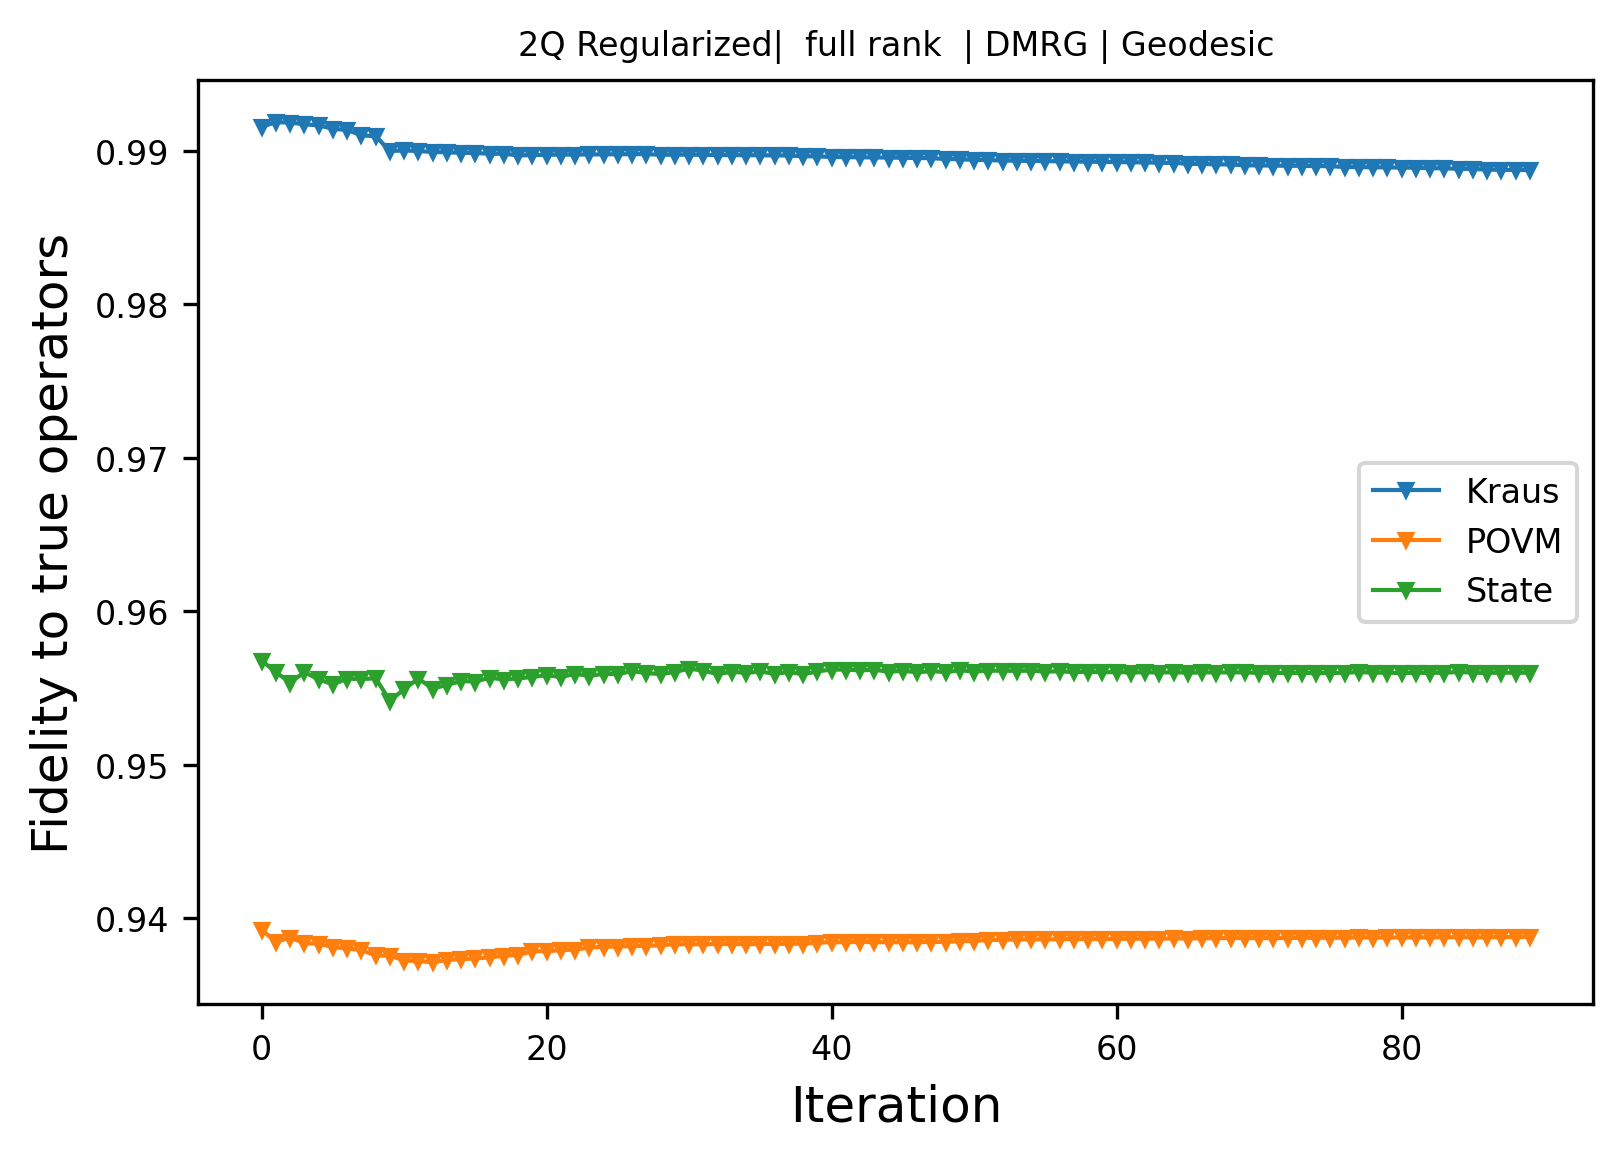

In [253]:
plot_step = 1
plt.figure(figsize=(6, 4), dpi=300)

kraus_tensor_fidelities_to_true_plot = jnp.array(kraus_tensor_fidelities_to_true) / num_gates

plt.plot(range(0, len(kraus_tensor_fidelities_to_true_plot), plot_step), kraus_tensor_fidelities_to_true_plot[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Kraus")

plt.plot(range(0, len(povm_fidelities_to_true), plot_step), povm_fidelities_to_true[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="POVM")

plt.plot(range(0, len(state_fidelities_to_true), plot_step), state_fidelities_to_true[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="State")

plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q Regularized|  full rank  | DMRG | Geodesic")
plt.ylabel("Fidelity to true operators", fontsize=12)
plt.legend()

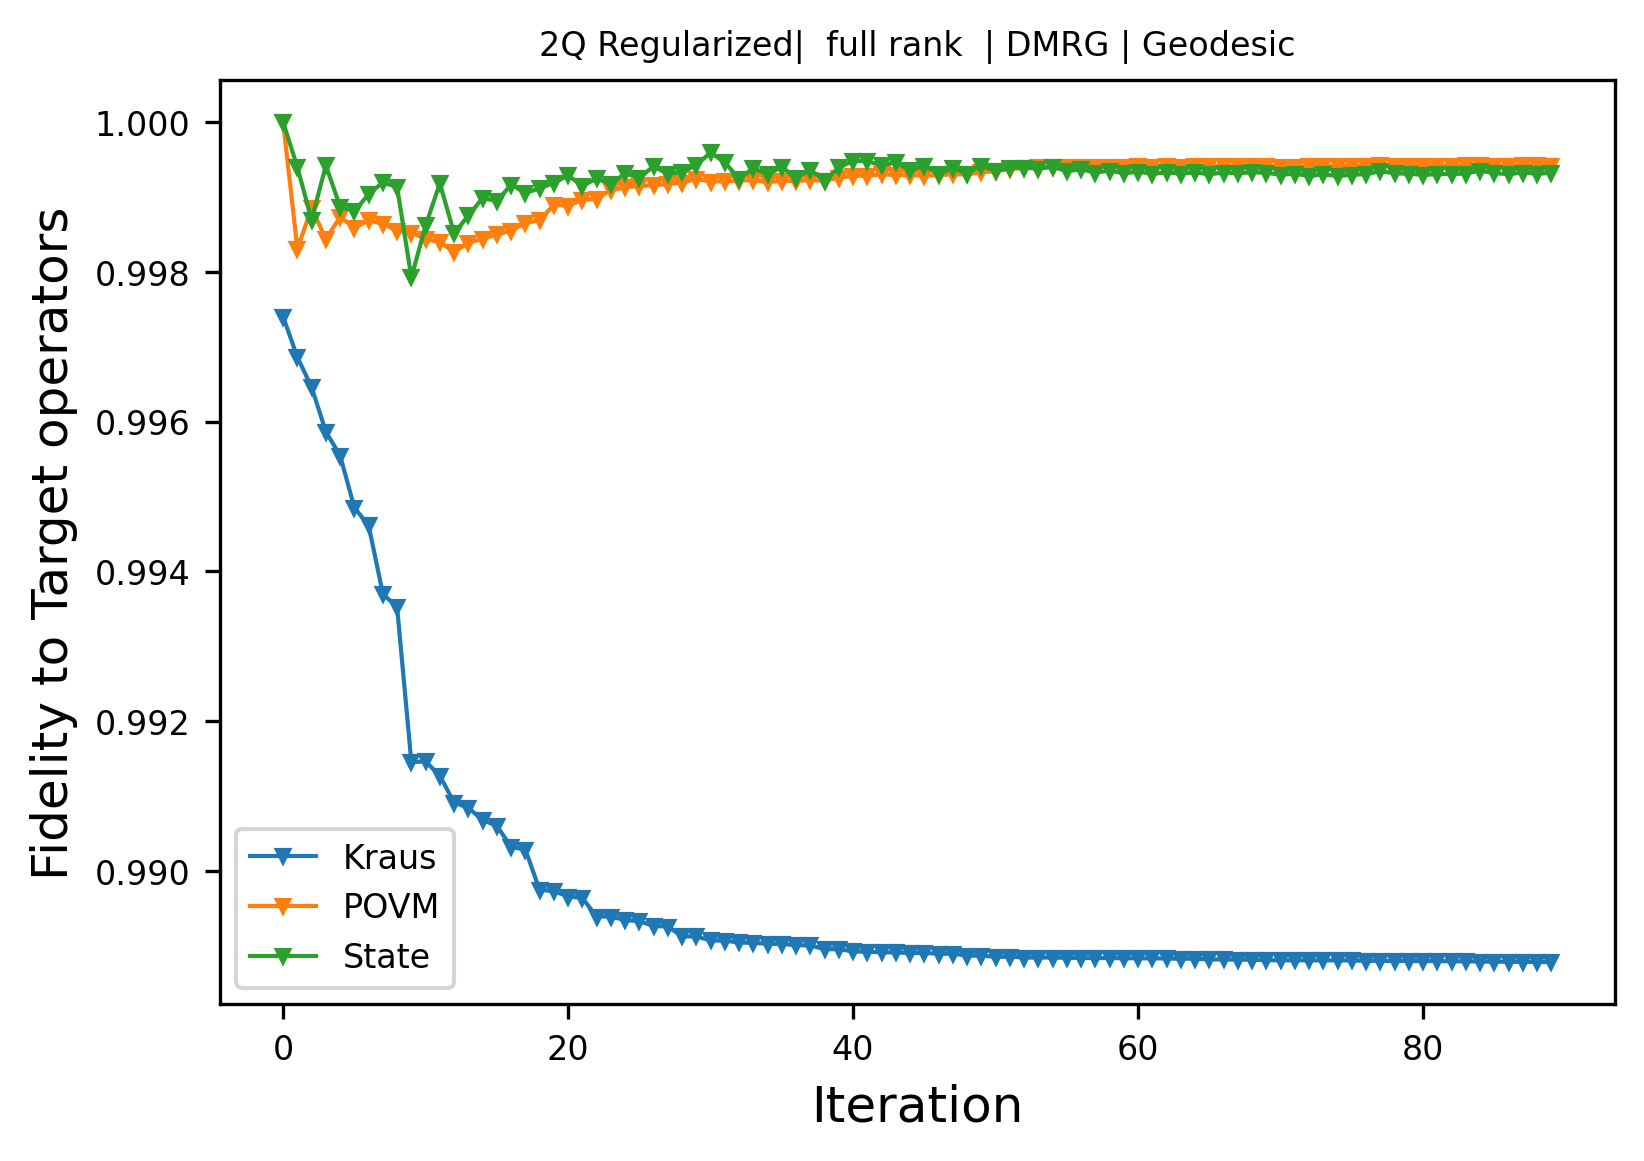

In [226]:
plot_step = 1
plt.figure(figsize=(6, 4), dpi=300)

kraus_tensor_fidelities_to_target_plot = jnp.array(kraus_tensor_fidelities_to_target) / num_gates

plt.plot(range(0, len(kraus_tensor_fidelities_to_target_plot), plot_step), kraus_tensor_fidelities_to_target_plot[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Kraus")

plt.plot(range(0, len(povm_fidelities_to_target), plot_step), povm_fidelities_to_target[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="POVM")

plt.plot(range(0, len(state_fidelities_to_target), plot_step), state_fidelities_to_target[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="State")

plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q Regularized|  full rank  | DMRG | Geodesic")
plt.ylabel("Fidelity to Target operators", fontsize=12)
plt.legend()

In [231]:
# cost function
probability_distance = []

for kraus, povm, state in zip(kraus_updated_2q_regularized_full_rank_100ls_perturbed, povm_updated_2q_regularized_full_rank_100ls_perturbed, state_updated_2q_regularized_full_rank_100ls_perturbed):
    distance = cost_function_jax_mps(kraus, povm, state, indices_list_2q, prob_matrix_2q_sampled, jit=True)
    probability_distance.append(distance)
    
probability_distance = jnp.array(probability_distance)
    

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count:

In [239]:
# I can also calculate what is the L(p_sampled, p_exact)
probability_distance_sampled = jnp.sum(jnp.abs(prob_matrix_exact - prob_matrix_2q_sampled)**2)
num_gate_sequences = len(indices_list_2q)
probability_distance_sampled = probability_distance_sampled / (num_gate_sequences * num_povm)
probability_distance_sampled

Array(0.00015166, dtype=float64)

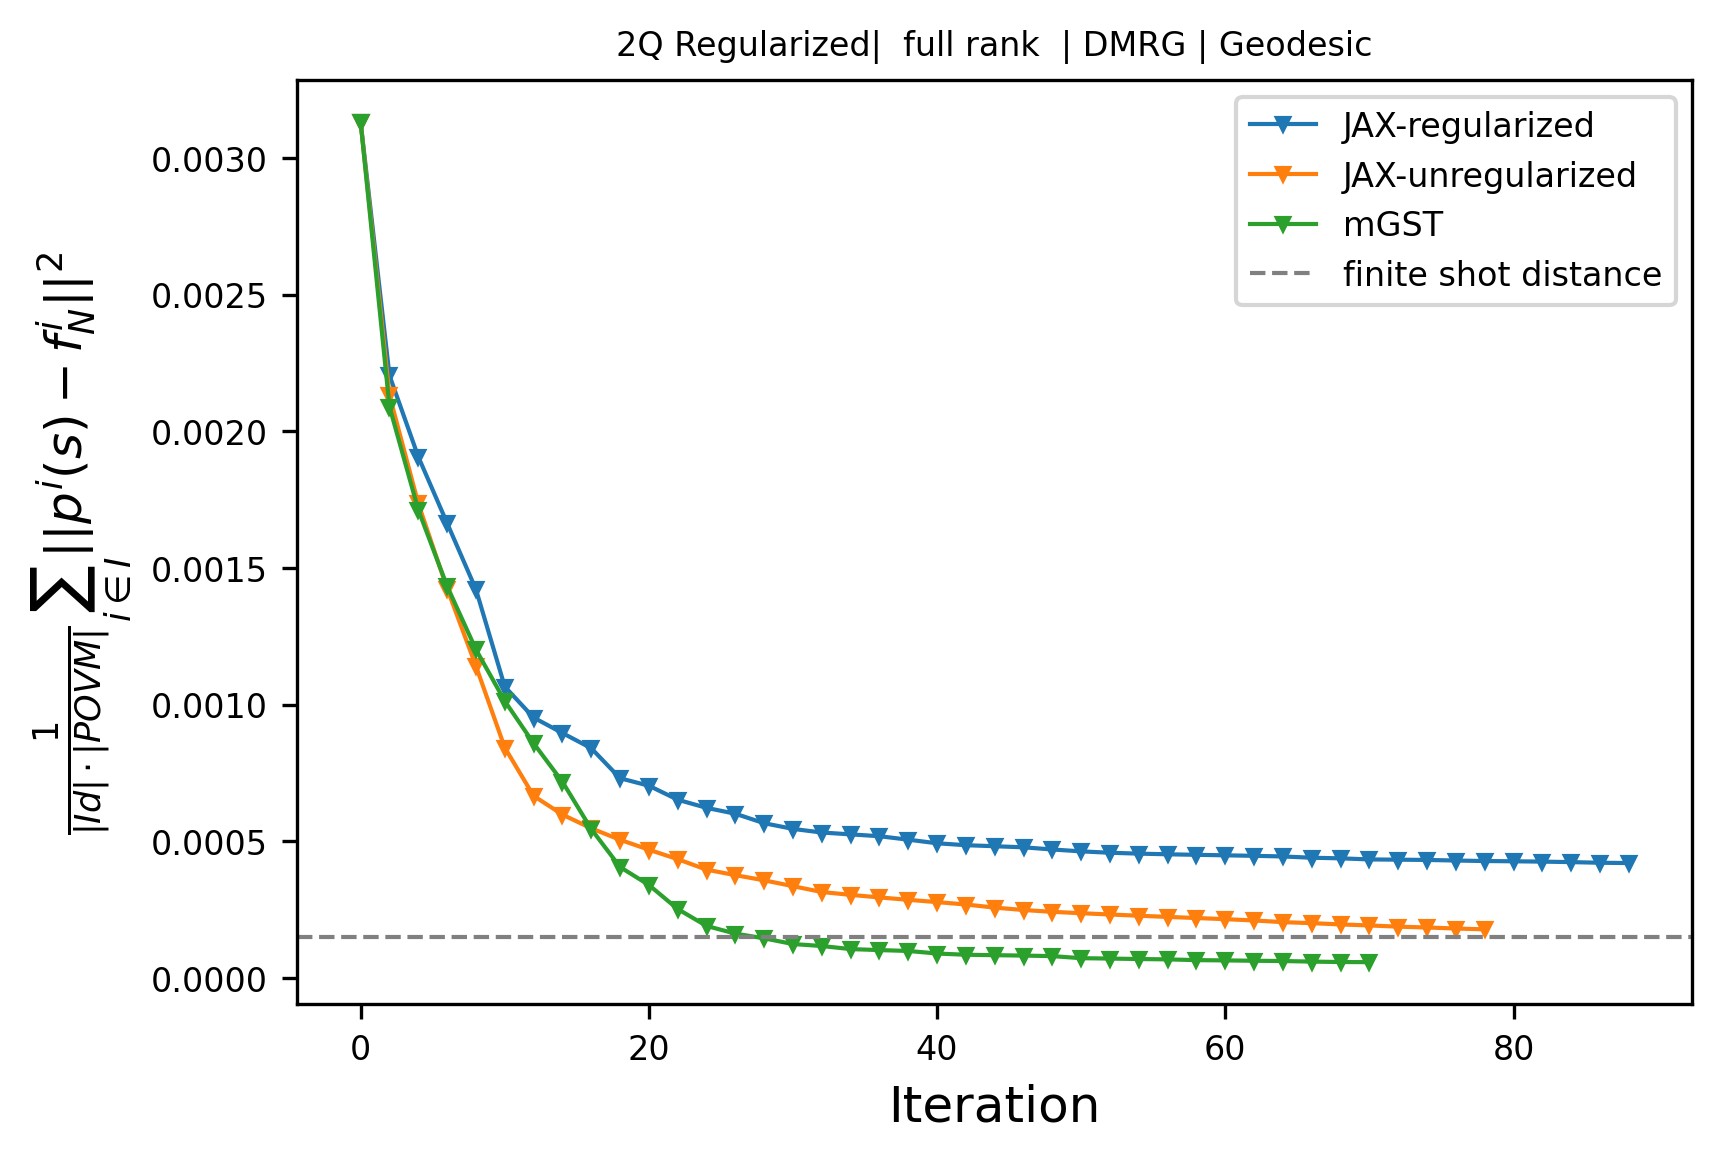

In [262]:
plot_step = 2
plt.figure(figsize=(6, 4), dpi=300)

plt.plot(range(0, len(probability_distance), plot_step), probability_distance[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="JAX-regularized")
max_idx_data = 80
plt.plot(range(0, len(cost_fn_history_2q_unregularized_perturbed_init[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_perturbed_init[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="JAX-unregularized")
plt.plot(range(0, len(cost_fn_history_2q_mgst), plot_step), cost_fn_history_2q_mgst[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="mGST")

plt.axhline(y=probability_distance_sampled, color='grey', linestyle='--', linewidth=1, label="finite shot distance")
plt.xlabel("Iteration", fontsize=12)
plt.title("2Q Regularized|  full rank  | DMRG | Geodesic")
plt.ylabel(r"$\frac{1}{|Id| \cdot |POVM|} \sum_{i \in I} ||p^i(s) - f^i_N||^2$", fontsize=12)
plt.legend()

In [246]:
from mGST.low_level_jit import compute_regularized_value_all_operators, cost_function_jax_mps_regularized, state_infidelity, process_infidelity

operator_distance_to_true = []

state_metric_to_true = lambda x, y : state_infidelity(x, y, pure=False)
kraus_metric_to_true = lambda x, y : process_infidelity(x, y, unitary=False)


for kraus, povm, state in zip(kraus_updated_2q_regularized_full_rank_100ls_perturbed, povm_updated_2q_regularized_full_rank_100ls_perturbed, state_updated_2q_regularized_full_rank_100ls_perturbed):
    distance = compute_regularized_value_all_operators(kraus, povm, state, kraus_tensor_target=kraus_tensor_2q_true, povm_psd_target=povm_psd_2q_true, state_psd_target=state_psd_2q_true, state_metric=state_metric_to_true,
                                                       kraus_metric=kraus_metric_to_true)
    operator_distance_to_true.append(distance)
    
operator_distance_to_true = jnp.array(operator_distance_to_true)

operator_distance_to_target = []

for kraus, povm, state in zip(kraus_updated_2q_regularized_full_rank_100ls_perturbed, povm_updated_2q_regularized_full_rank_100ls_perturbed, state_updated_2q_regularized_full_rank_100ls_perturbed):
    distance = compute_regularized_value_all_operators(kraus, povm, state, kraus_tensor_target=kraus_tensor_2q_target, povm_psd_target=povm_psd_2q_target, state_psd_target=state_psd_2q_target)
    operator_distance_to_target.append(distance)
    
operator_distance_to_target = jnp.array(operator_distance_to_target)

regularized_values_test = []

for kraus, povm, state in zip(kraus_updated_2q_regularized_full_rank_100ls_perturbed, povm_updated_2q_regularized_full_rank_100ls_perturbed, state_updated_2q_regularized_full_rank_100ls_perturbed):
    distance = cost_function_jax_mps_regularized(
        kraus, povm, state,
        indices_list_2q, prob_matrix_2q_sampled,
        target_kraus_tensor=kraus_tensor_2q_target, target_povm_psd=povm_psd_2q_target, target_state_psd=state_psd_2q_target, num_samples=shots, jit=True)
    regularized_values_test.append(distance)


regularized_values_test = jnp.array(regularized_values_test)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial co

In [250]:
compute_regularized_value_all_operators(
    kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target,
    kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target,
    state_metric=state_metric_to_true, kraus_metric=kraus_metric_to_true
)

Array(-8.8817842e-15, dtype=float64)

In [1052]:
10/1000

0.01

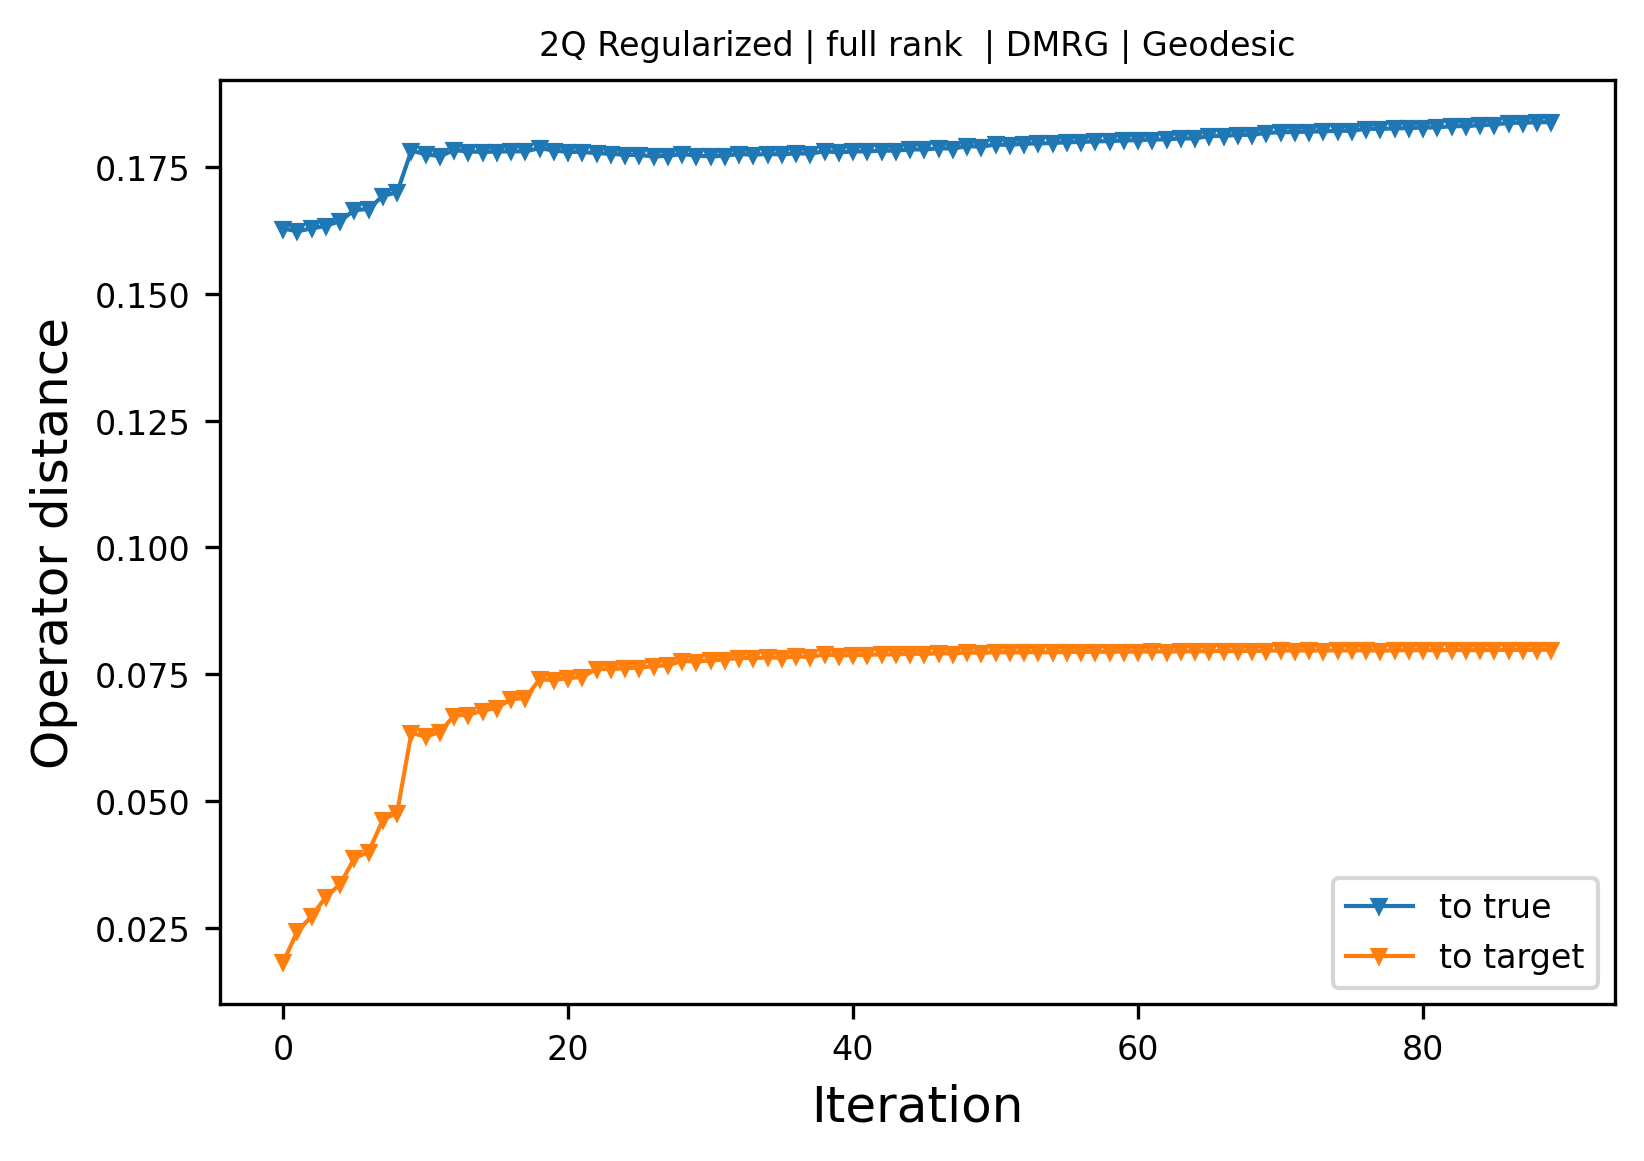

In [252]:
plot_step = 1
plt.figure(figsize=(6, 4), dpi=300)

plt.plot(range(0, len(operator_distance_to_true), plot_step), operator_distance_to_true[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="to true")

plt.plot(range(0, len(operator_distance_to_target), plot_step), operator_distance_to_target[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="to target")

# plt.plot(range(0, len(regularized_values_test), plot_step), regularized_values_test[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="to target")

plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q Regularized | full rank  | DMRG | Geodesic")
plt.ylabel("Operator distance", fontsize=12)
plt.legend()

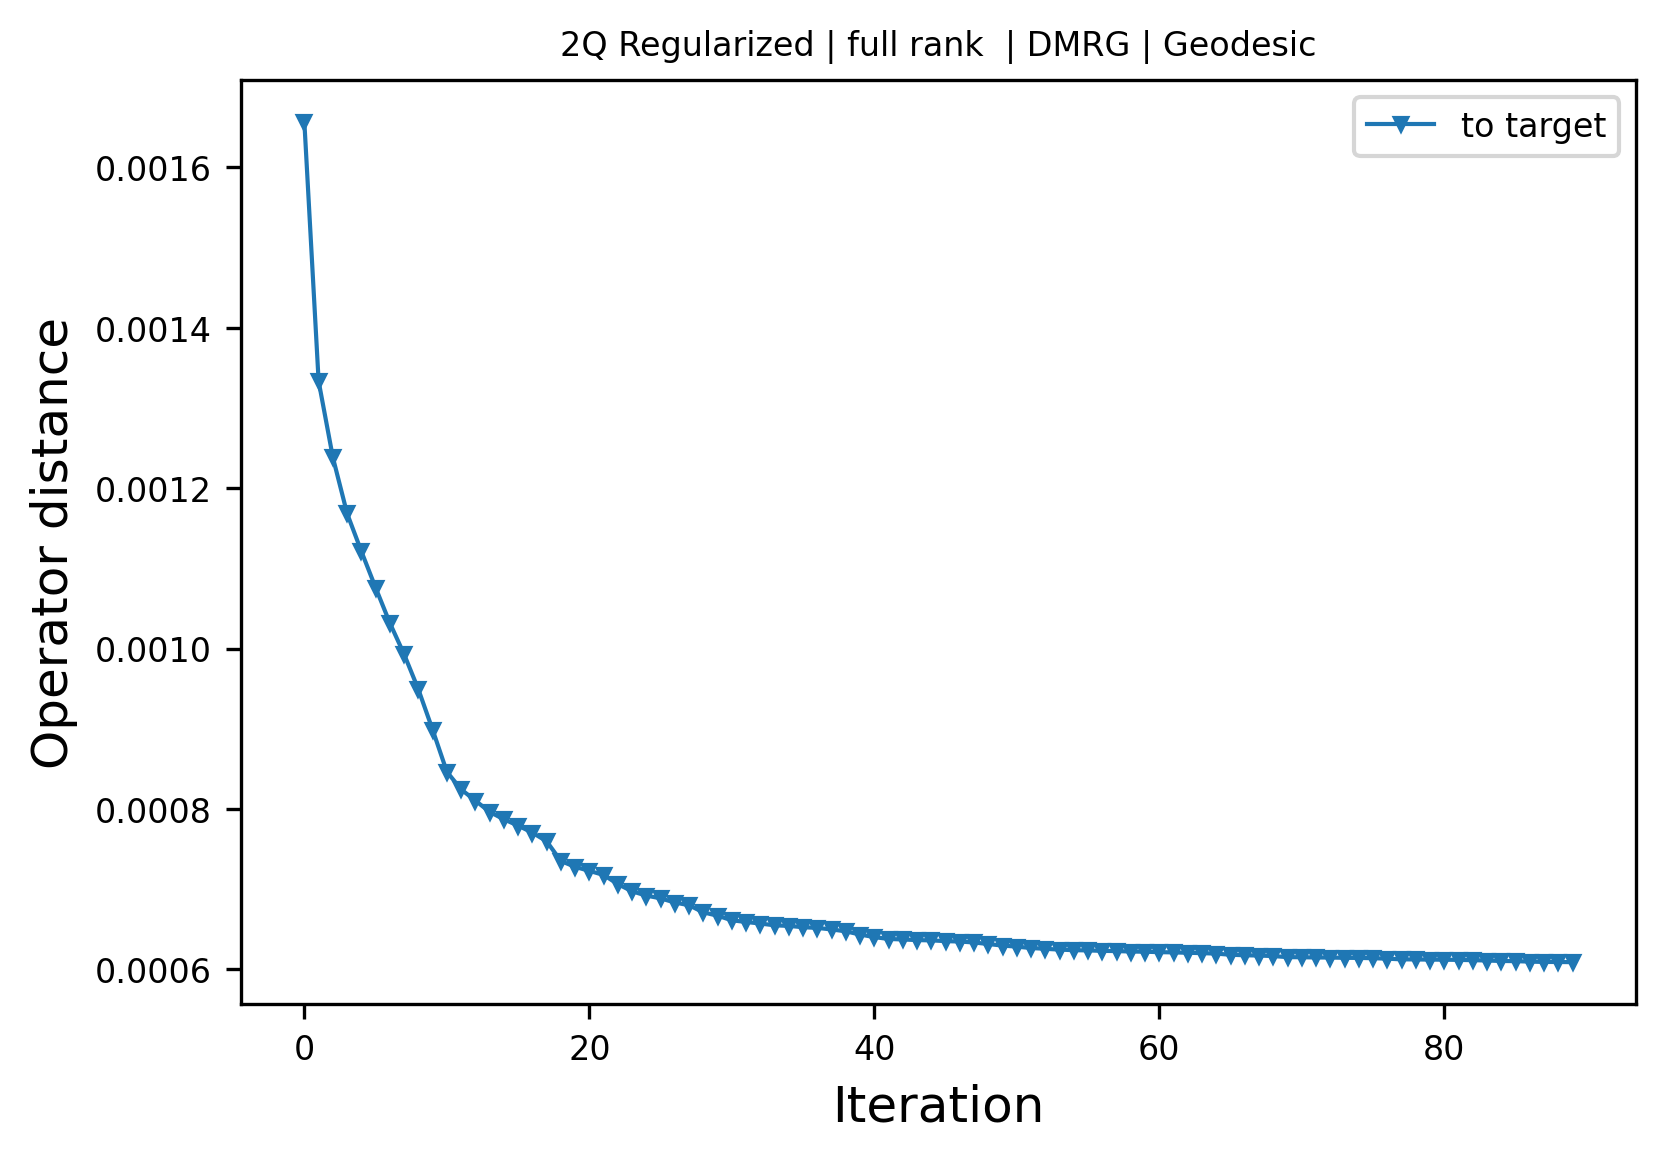

In [254]:
loss_function_values = 0.5* (probability_distance + (10/shots) * operator_distance_to_target)

plot_step = 1
plt.figure(figsize=(6, 4), dpi=300)

plt.plot(range(0, len(loss_function_values), plot_step), loss_function_values[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="to target")

plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q Regularized | full rank  | DMRG | Geodesic")
plt.ylabel("Operator distance", fontsize=12)
plt.legend()

Notes: 

* Somehow the cost function from the optimization is not matchingt the values I am calculating individually. What is wrong?

* In theory these should match. There is of course a bit of a mismatch that we have one less iteration in the cost function, but that shouldn't be an issue.